# Zaawansowane Uczenie Maszynowe

## Dokumentacja projektu

### *Analiza przeżycia w przewidywaniu czasu zagrożenia stref ewakuacyjnych przez pożary lasów*

**Grzegorz Statkiewicz, Filip Langiewicz**

*7 czerwca 2026*

## 1. Temat projektu

W ramach projektu zostanie zrealizowane zadanie konkursowe [WiDS Global Datathon 2026](https://www.wids.org/) jako zadanie analityczne. Zadanie dotyczy prognozowania zagrożenia pożarowego dla stref ewakuacyjnych. Dla każdego pożaru udostępnione są cechy obliczone wyłącznie na podstawie pierwszych pięciu godzin od momentu wykrycia ogniska ($t_0$), opisujące dynamikę rozprzestrzeniania się ognia oraz jego położenie względem stref ewakuacyjnych.

Celem jest estymacja prawdopodobieństwa zdarzenia, że pożar zagrozi strefie ewakuacyjnej (zbliży się na odległość poniżej 5 km od jej centroidu) w horyzoncie 12, 24, 48 oraz 72 godzin, zaczynając od momentu $t_0 + 5h$. Zadanie sformułowane jest jako problem **analizy przeżycia** (ang. *survival analysis*), gdzie dla każdego pożaru należy podać cztery kolejne wartości prawdopodobieństwa wystąpienia zdarzenia. Dodatkowo w zadaniu pojawiają się obserwacje cenzurowane do pierwszych 72 godzin, stąd ewentualne zdarzenie mogło nie nastąpić lub nastąpiło później, lecz nie zostało odnotowane.

## 2. Zbiór danych

Zbiór składa się z 316 pożarów podzielonych na część treningową (221 próbek, w tym 69 ze zdarzeniem i 152 cenzurowanych, bez zarejestrowanego zdarzenia) oraz testową (95 próbek). Autorzy zaznaczyli, iż niewielki rozmiar zbioru wynika z tego, że tylko nieliczne pożary posiadają jednocześnie wystarczająco wczesne i dokładne obserwacje. [https://www.kaggle.com/competitions/WiDSWorldWide_GlobalDathon26]

Każdy pożar opisany jest 34 cechami obliczonymi z pierwszych pięciu godzin po wykryciu ($t_0$). Obejmują one:

- **cechy wzrostu pożaru** — powierzchnia początkowa, przyrost bezwzględny i względny, tempo wzrostu promieniowego,
- **kinematykę centroidu pożaru** — przemieszczenie, prędkość, kierunek rozprzestrzeniania,
- **odległość do stref ewakuacyjnych i jej dynamikę** — odległość minimalna, prędkość zbliżania, przyspieszenie, dopasowanie liniowe,
- **miary kierunkowości** — wyrównanie ruchu ognia względem strefy ewakuacyjnej,
- **dane czasowe** — godzina, dzień tygodnia, miesiąc rozpoczęcia pożaru.

Etykiety stanowią zmienne `time_to_hit_hours`, czyli czas od $t_0 + 5h$ do momentu zbliżenia się pożaru na odległość poniżej 5 km od centroidu strefy ewakuacyjnej lub do końca czasu obserwacji (obserwacja cenzurowana), oraz zmienna `event`, przyjmująca wartość 1, gdy pożar dotarł w ciągu 72 h, i 0 w przeciwnym przypadku (obserwacja cenzurowana).

Po wstępnej analizie zbiór nie zawiera brakujących wartości ani zduplikowanych obserwacji. Potencjalnym obszarem do zaadresowania podczas eksperymentów będzie inżynieria cech.

## 3. Miary jakości

Docelową miarę oceny zadania konkursowego definiuje się następująco:

$$
\text{Hybrid Score} = 0{,}3 \cdot \text{C-index} + 0{,}7 \cdot (1 - \text{Weighted Brier Score}),
$$

gdzie `C-index` (indeks zgodności) mierzy, na ile dobrze model porządkuje pożary według pilności zagrożenia oraz przyjmuje wartości od 0,5 (losowy) do 1,0 (idealny). `Weighted Brier Score` ocenia kalibrację prawdopodobieństw w trzech horyzontach czasowych z użyciem wyniku Brier'a i odpowiednich wag:

$$
\text{Weighted Brier} = 0{,}3 \cdot \text{Brier}_{24\text{h}} + 0{,}4 \cdot \text{Brier}_{48\text{h}} + 0{,}3 \cdot \text{Brier}_{72\text{h}}
$$

gdzie dla każdego horyzontu $H$ obserwacje cenzurowane przed $H$ są wykluczane, a obserwacje cenzurowane po $H$ traktowane są jako brak zdarzenia. Najwyższą wagę ma horyzont 48h.

## 4. Proponowane algorytmy

Zadanie można rozpatrywać na wiele sposobów. Po pierwsze można do niego podejść jak do problemu analizy przeżycia (przewidywanie czasu oraz prawdopodobieństwa braku zajścia zdarzenia do danego czasu). Można również wziąć pod uwagę zwykłą klasyfikację binarną (dla każdego horyzontu przyporządkowujemy klasę 0 lub 1) lub regresję (przewidywanie czasu zdarzenia). Ze względu na problem cenzurowania podejścia klasyfikacyjne oraz regresja będą wykorzystane jako podejścia bazowe. Poniżej zamieszczono szczegółowe informacje o zastosowanych algorytmach.

| Zadanie | Model | Biblioteka | Klasa |
|---|---|---|---|
| Regresja | Regresja liniowa | `scikit-learn` | `LinearRegression` |
| Klasyfikacja | Regresja logistyczna | `scikit-learn` | `LogisticRegression` |
| Klasyfikacja | Decision Tree | `scikit-learn` | `DecisionTreeClassifier` |
| Klasyfikacja | Random Forest | `scikit-learn` | `RandomForestClassifier` |
| Klasyfikacja | Gradient Boosting | `scikit-learn` | `GradientBoostingClassifier` |
| Klasyfikacja | SVM | `scikit-learn` | `SVC` |
| Klasyfikacja | KNN | `scikit-learn` | `KNeighborsClassifier` |
| Analiza przeżycia | Kaplan–Meier | `lifelines` | `KaplanMeierFitter` |
| Analiza przeżycia | Model Coxa | `lifelines` | `CoxPHFitter` |
| Analiza przeżycia | Random Survival Forest | `scikit-survival` | `RandomSurvivalForest` |
| Analiza przeżycia | Gradient Boosting Survival | `scikit-survival` | `GradientBoostingSurvivalAnalysis` |

W stosunku do dokumentacji wstępnej zbiór klasyfikatorów został rozszerzony o modele `DecisionTreeClassifier`, `SVC` oraz `KNeighborsClassifier`. Dla trzech najlepszych modeli klasyfikacyjnych przeprowadzono dodatkowo strojenie hiperparametrów z użyciem stratyfikowanej walidacji krzyżowej.

## 5. Plan eksperymentów

### 5.1 Przygotowanie danych

Przed modelowaniem przeprowadzone zostały: standaryzacja cech ciągłych (`StandardScaler`),
cykliczne kodowanie cech czasowych (sin/cos) oraz inżynieria cech wyższego rzędu
(m.in. iloczyn prędkości zbliżania i odległości minimalnej). Dla podejść klasyfikacyjnych
każdy pożar został zduplikowany dla każdego horyzontu $H \in \{12, 24, 48, 72\}$ h
z etykietą binarną wyznaczoną z par (`time_to_hit_hours`, `event`); obserwacje
cenzurowane przed danym horyzontem zostały wykluczone.

### 5.2 Hipotezy badawcze

1. **H1:** Czy modele analizy przeżycia (Cox PH, RSF, GBSA), uwzględniające cenzurowanie,
   osiągają wyższy Hybrid Score niż klasyfikatory binarne lub regresja ignorujące ten mechanizm?
2. **H2:** Czy nieliniowe modele drzewiaste osiągają wyższy C-index niż model Coxa?
3. **H3:** Czy inżynieria cech wyższego rzędu poprawia wyniki, szczególnie dla modeli liniowych?

### 5.3 Parametry algorytmów

W poniższej tabeli przedstawione są parametry algorytmów planowane do strojenia.


| Model | Parametr | Zakres / wartości |
|---|---|---|
| Regresja logistyczna | `C` / `penalty` | {0.01, 0.1, 1, 10} / `l1`, `l2` |
| Drzewo decyzyjne | `max_depth` / `min_samples_leaf` | {3, 5, 10, None} / {1, 5, 10} |
| Random Forest | `n_estimators` / `max_depth` | {100, 300, 500} / {3, 5, 10, None} |
| Gradient Boosting | `learning_rate` / `max_depth` | {0.01, 0.05, 0.1} / {2, 3, 4} |
| SVM | `C` / `kernel` / `gamma` | {0.1, 1, 10} / `rbf`, `linear` / `scale`, `auto` |
| k-NN | `n_neighbors` / `weights` | {3, 5, 7, 11, 15} / `uniform`, `distance` |
| Regresja liniowa | — | brak strojenia |
| Cox PH | `penalizer` | {0.0, 0.01, 0.1, 1.0} |
| Random Survival Forest | `n_estimators` / `min_samples_leaf` | {100, 300, 500} / {5, 10, 20} |
| Gradient Boosting Survival | `learning_rate` / `max_depth` | {0.01, 0.05, 0.1} / {2, 3, 4} |

W stosunku do dokumentacji wstępnej zestaw modeli klasyfikacyjnych został rozszerzony, co pozwala na szersze porównanie podejść.

### 5.4 Procedura oceny modeli

Ze względu na mały rozmiar zbioru (221 próbek) zastosowana została **walidacja krzyżowa**,
a strojenie hiperparametrów realizowane było przez `GridSearchCV`. Podstawową miarą wyboru
modelu jest Hybrid Score; pomocniczo raportowane są C-index, Weighted Brier
Score oraz *time-dependent AUC* (`sksurv.metrics.cumulative_dynamic_auc`).

## 6. Eksperymenty

Kod eksperymentów został umieszczony w repozytorium GitHub [WiDS2026WildfireSurvival](https://github.com/FilipLangiewicz/WiDS2026WildfireSurvival), które zawiera funkcje pomocnicze oraz kod odpowiedzialny za konfiguracje, uruchomienie oraz ewaluację kolejnych modeli. Uruchomienie notebook'a nie powinno zająć więcej niż 10 min.

### 6.1 Przygotowanie środowiska

In [51]:
!git clone https://github.com/FilipLangiewicz/WiDS2026WildfireSurvival.git

Cloning into 'WiDS2026WildfireSurvival'...
remote: Enumerating objects: 125, done.
remote: Counting objects: 100% (125/125), done.
remote: Compressing objects: 100% (101/101), done.
remote: Total 125 (delta 36), reused 105 (delta 20), pack-reused 0 (from 0)
Receiving objects: 100% (125/125), 4.30 MiB | 21.07 MiB/s, done.
Resolving deltas: 100% (36/36), done.


In [52]:
import os
import sys
import warnings
from pathlib import Path

REPO_NAME = "WiDS2026WildfireSurvival"

ROOT = Path("/content") / REPO_NAME
DATA = ROOT / "data"
STORAGE = Path("/content")
RESULTS = STORAGE / "results"
ARTIFACTS = STORAGE / "artifacts"

warnings.filterwarnings("ignore")

os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
os.environ["WIDS_STORAGE_DIR"] = str(STORAGE)

for path in [RESULTS, ARTIFACTS]:
    path.mkdir(parents=True, exist_ok=True)

In [53]:
%pip install -q -r requirements.txt

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import data_loader as dl
from src import evaluation as ev
from src import models as M
from src import preprocessing as pp
from src.utils import HORIZONS, save_figure, save_model_bundle, save_table, set_global_seed

set_global_seed()

print("Setup complete")
print("ROOT:", ROOT)
print("DATA:", DATA)
print("RESULTS:", RESULTS)
print("ARTIFACTS:", ARTIFACTS)

Setup complete
ROOT: /content/WiDS2026WildfireSurvival
DATA: /content/WiDS2026WildfireSurvival/data
RESULTS: /content/results
ARTIFACTS: /content/artifacts


Środowisko gotowe — pobrano dane konkursowe oraz moduły pomocnicze projektu.

### 6.2 Eksploracyjna analiza danych i inżynieria cech

In [55]:
train, test, submission, meta = dl.load_raw(folder=DATA)
features = dl.feature_columns(train)

print('train:', train.shape, '| test:', test.shape, '| features:', len(features))
print('missing train/test:', int(train.isna().sum().sum()), int(test.isna().sum().sum()), '| duplicate rows:', int(train.duplicated().sum()))

train: (221, 37) | test: (95, 35) | features: 34
missing train/test: 0 0 | duplicate rows: 0


Zbiór treningowy zawiera **221 próbek i 34 cechy** pogrupowane w 8 kategorii
(pokrycie czasowe, wzrost pożaru, kinematyka centroidu, odległość, kierunkowość,
metadane temporalne). Zbiór testowy liczy 95 próbek. Dane są kompletne —
brak braków danych i zduplikowanych wierszy, co eliminuje konieczność imputacji.

In [56]:
meta[['column', 'category', 'description']]

,column,category,description
0,event_id,identifier,Anonymized fire event identifier (stable rando...
1,time_to_hit_hours,target,Time from t0+5h until fire comes within 5km of...
2,event,target,"Event indicator: 1 if fire hit within 72h, 0 i..."
3,num_perimeters_0_5h,temporal_coverage,Number of perimeters within first 5 hours
4,dt_first_last_0_5h,temporal_coverage,Time span between first and last perimeter (ho...
5,low_temporal_resolution_0_5h,temporal_coverage,"Flag: 1 if dt < 0.5h or only 1 perimeter, else 0"
6,area_first_ha,growth,Initial fire area at t0 (hectares)
7,area_growth_abs_0_5h,growth,Feature from growth category
8,area_growth_rel_0_5h,growth,Feature from growth category
9,area_growth_rate_ha_per_h,growth,Area growth rate (hectares per hour)


Każda cecha posiada przypisaną kategorię oraz opis. Cechy docelowe to
`time_to_hit_hours` (czas do zdarzenia w godzinach) oraz `event` (wskaźnik
zdarzenia: 1 jeśli pożar dotarł do strefy ewakuacji w ciągu 72h, 0 jeśli
cenzurowany). Pozostałe 34 cechy opisują wczesną fazę pożaru (pierwsze 5h)
i stanowią wejście do modeli.

event
censored (0)    152
hit (1)          69


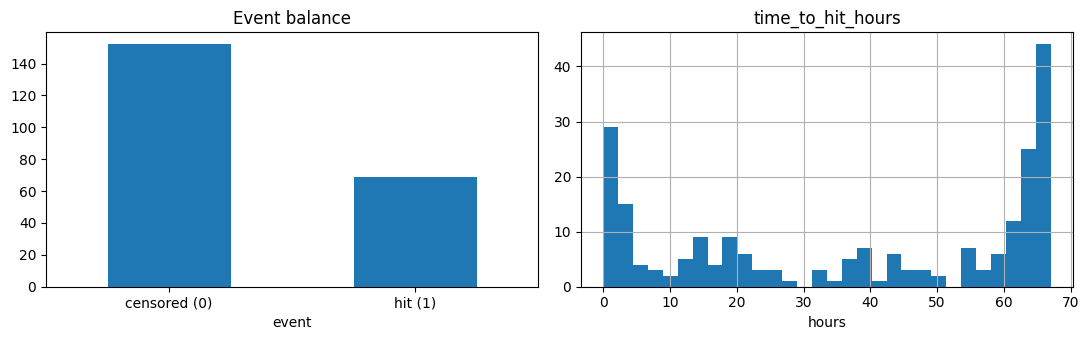

In [57]:
ev_counts = train['event'].value_counts().rename({0:'censored (0)', 1:'hit (1)'})
print(ev_counts.to_string())
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ev_counts.plot(kind='bar', ax=ax[0], title='Event balance')
ax[0].tick_params(axis='x', rotation=0)
train['time_to_hit_hours'].hist(bins=30, ax=ax[1])
ax[1].set_title('time_to_hit_hours')
ax[1].set_xlabel('hours')
fig.tight_layout()
save_figure(fig, 'dataset/eda_target.png')
plt.show()

Zbiór jest niezbalansowany — 152 przypadki cenzurowane (69%) wobec 69 zdarzeń
rzeczywistych (31%).

In [58]:
label_tbl = dl.label_summary(train, HORIZONS)
save_table(label_tbl, "dataset/label_summary.csv")
label_tbl

,horizon_h,positives,negatives,excluded,usable
0,12,49,166,6,215
1,24,63,133,25,196
2,48,66,100,55,166
3,72,69,152,0,221


Dla horyzontu 12h zbiór jest najbardziej niezbalansowany — jedynie 49 przypadków
pozytywnych (pożarów które dotarły do strefy) na 215 użytecznych próbek.
Wraz ze wzrostem horyzontu liczba pozytywów rośnie (49 → 69), ale rośnie też
liczba wykluczonych obserwacji cenzurowanych (6 → 55 dla 48h), co zmniejsza
efektywny rozmiar zbioru. Wyjątkiem jest horyzont 72h — brak wykluczeń,
bo etykieta jest tożsama z `event` (pełne okno obserwacji).

category
centroid_kinematics     5
directionality          4
distance                9
growth                 10
identifier              1
temporal_coverage       3
temporal_metadata       3


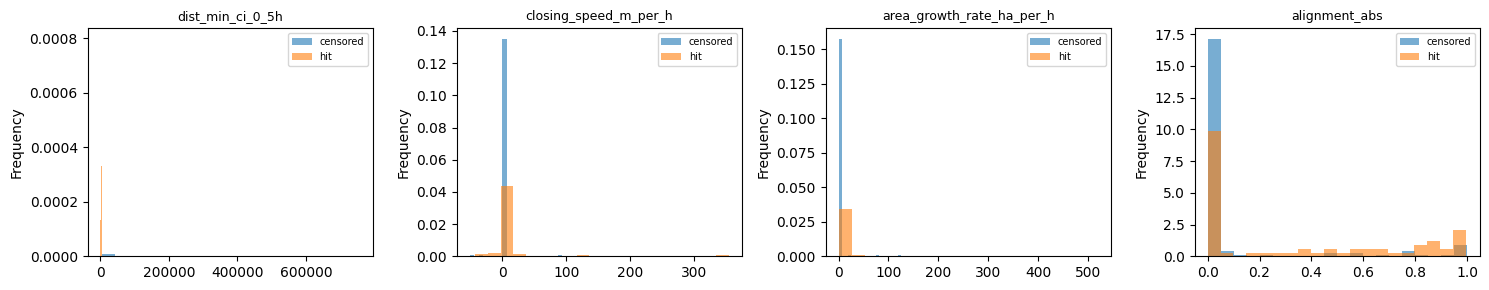

In [59]:
## Feature groups and a few distributions
print(meta[meta.category != 'target'].groupby('category')['column'].count().to_string())

key = ['dist_min_ci_0_5h', 'closing_speed_m_per_h', 'area_growth_rate_ha_per_h', 'alignment_abs']
fig, ax = plt.subplots(1, 4, figsize=(15, 3))
for a, c in zip(ax, key):
    for v, lab in [(0, 'censored'), (1, 'hit')]:
        train.loc[train.event == v, c].plot(kind='hist', bins=20, alpha=0.6, ax=a, label=lab, density=True)
    a.set_title(c, fontsize=9)
    a.legend(fontsize=7)
fig.tight_layout()
save_figure(fig, "dataset/eda_feature_dists.png")
plt.show()

34 cechy dzielą się na 6 grup: distance (9), growth (10),
centroidkinematics (5), directionality (4), temporalcoverage (3),
temporalmetadata (3). Histogramy czterech kluczowych cech (distminci05h,
closingspeedmperh, areagrowthratehaperh, alignmentabs) pokazują wyraźną
separację między pożarami, które dotarły do strefy ewakuacyjnej (hit),
a cenzurowanymi — szczególnie widoczną dla odległości i prędkości zbliżania.

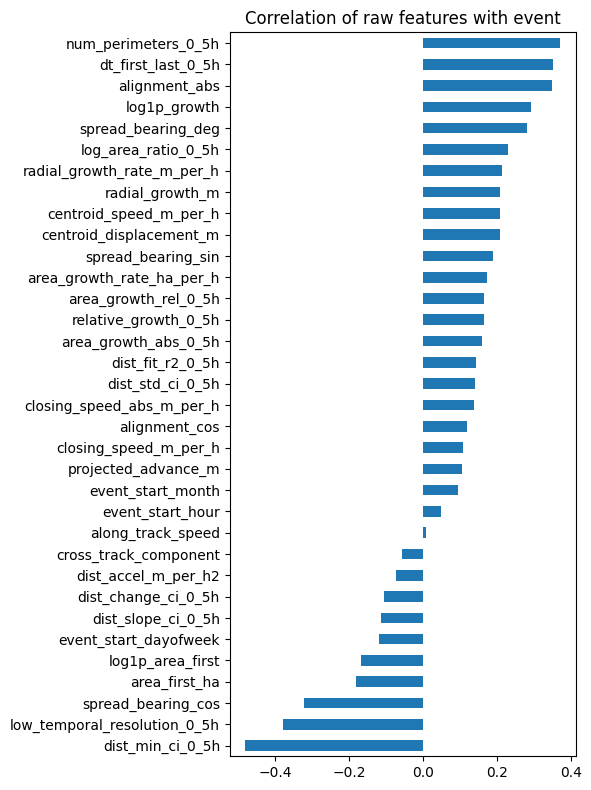

In [60]:
corr = train[features + ['event']].corr()['event'].drop('event').sort_values()
fig, ax = plt.subplots(figsize=(6, 8))
corr.plot(kind='barh', ax=ax)
ax.set_title('Correlation of raw features with event')
fig.tight_layout()
save_figure(fig, "dataset/eda_corr_event.png")
plt.show()

Najsilniej z etykietą korelują cechy dystansowe i prędkościowe —
dist_min_ci_0_5h silnie negatywnie (bliżej = większe ryzyko), closing_speed_m_per_h
i projected_advance_m pozytywnie. Cechy wzrostu obszaru (growth) i kierunkowości
mają umiarkowany, ale stabilny sygnał, natomiast temporal_metadata pozostają
praktycznie nieskorelowane z etykietą binarną.

In [61]:
## Feature engineering
eng = pp.engineer_features(train[features])
new_cols = [c for c in eng.columns if c not in features]
print('raw features', len(features), '→ engineered', eng.shape[1])
print('added:', new_cols)
print('NaNs after FE:', int(eng.isna().sum().sum()))
eng[new_cols].describe().T.round(3)

raw features 34 → engineered 41
added: ['event_start_hour_sin', 'event_start_hour_cos', 'event_start_dayofweek_sin', 'event_start_dayofweek_cos', 'event_start_month_sin', 'event_start_month_cos', 'approach_urgency', 'est_hours_to_zone', 'closing_x_alignment', 'growth_x_closing', 'advance_ratio']
NaNs after FE: 0


,count,mean,std,min,25%,50%,75%,max
event_start_hour_sin,221.0,-0.405,0.585,-1.000,-0.866,-0.707,0.000,1.000
event_start_hour_cos,221.0,0.460,0.534,-1.000,0.000,0.707,0.866,1.000
event_start_dayofweek_sin,221.0,0.088,0.712,-0.975,-0.782,0.434,0.782,0.975
event_start_dayofweek_cos,221.0,0.020,0.700,-0.901,-0.901,-0.223,0.623,1.000
event_start_month_sin,221.0,-0.367,0.591,-1.000,-0.866,-0.500,0.000,1.000
event_start_month_cos,221.0,-0.636,0.337,-1.000,-0.866,-0.866,-0.500,0.866
approach_urgency,221.0,0.001,0.010,-0.024,0.000,0.000,0.000,0.127
est_hours_to_zone,221.0,9652.248,1803.268,0.000,10000.000,10000.000,10000.000,10000.000
closing_x_alignment,221.0,2.011,23.998,-30.989,0.000,0.000,0.000,319.639
growth_x_closing,221.0,960.380,12422.427,0.000,0.000,0.000,0.000,184299.754


Do 34 surowych cech dodano 7 kolumn (łącznie 41):
cykliczne kodowanie sin/cos dla godziny, dnia tygodnia i miesiąca startu, oraz cztery cechy interakcyjne
bezpośrednio związane z wielkościami fizycznymi. Żaden z nowych
atrybutów nie generuje wartości NaN.

Cały preprocessing (imputacja, skalowanie, enkodowanie) jest hermetycznie
zamknięty w src/preprocessing.build_preprocessor i wpinany bezpośrednio
do pipeline'ów sklearn. Dzięki temu fit scalera odbywa się wyłącznie na
danych treningowych każdego foldu CV — brak wycieków do walidacji.

### 6.3 Modele klasyfikacyjne i regresyjne


Zdefiniowano 6 modeli bazowych dla ścieżki klasyfikacyjnej: regresja logistyczna, drzewo
decyzyjne, las losowy, gradient boosting, SVM i k-NN. `FAST=False` oznacza pełne siatki hiperparametrów do przeszukania, w.p.p. są one ograniczone do 1-2 wartości dla szybszej iteracji.


In [62]:
train, test, submission, meta = dl.load_raw(folder=DATA)
features = dl.feature_columns(train)

def prep():
    return pp.build_preprocessor(use_interactions=True, scale=True)

In [63]:
N_SPLITS = 5
FAST = False

non_survival_models = M.get_default_models(fast=FAST)
print('classification models:', list(non_survival_models))

classification models: ['logistic_regression', 'decision_tree', 'random_forest', 'gradient_boosting', 'svm', 'knn']


Dla każdego z czterech horyzontów czasowych (12h, 24h, 48h, 72h) przeprowadzono
stratyfikowaną k-krotną walidację krzyżową (k=5).
Metryką oceny jest ROC-AUC.

In [64]:
summary, oof = ev.evaluate_models_per_horizon(non_survival_models, prep, train, features, n_splits=N_SPLITS)
save_table(summary, 'classification/cv_generic_summary.csv')
summary.pivot(index='model', columns='horizon_h', values='roc_auc').round(3)

horizon_h,12,24,48,72
model,,,,
decision_tree,0.837,0.918,0.975,1.000
gradient_boosting,0.958,0.988,0.989,1.000
knn,0.756,0.804,0.799,0.748
logistic_regression,0.904,0.894,0.904,0.891
random_forest,0.947,0.985,0.992,0.999
svm,0.849,0.855,0.845,0.850


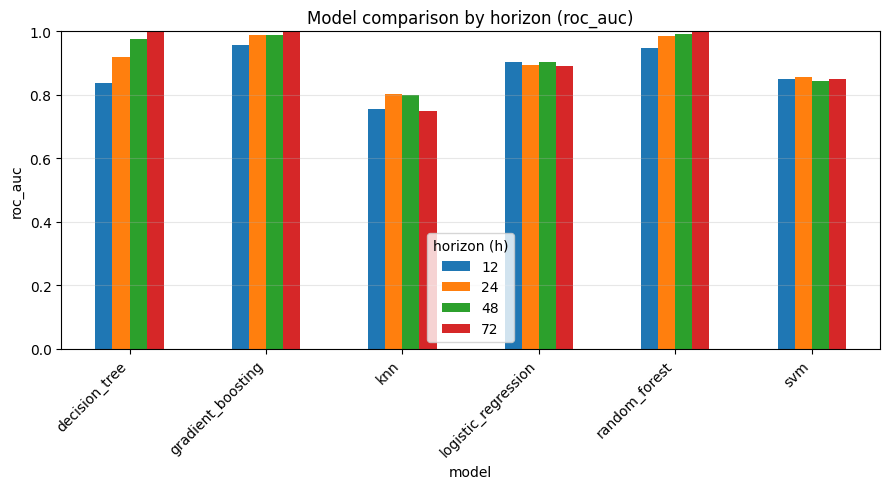

In [65]:
fig = ev.plot_model_comparison(summary, 'roc_auc')
save_figure(fig, "classification/model_comparison_rocauc.png")
plt.show()

Przedstawiono pogrupowany wykres słupkowy — ROC-AUC każdego modelu dla czterech horyzontów
czasowych. Gradient boosting i las losowy dominują na wszystkich horyzontach;
k-NN wypada najsłabiej, szczególnie na horyzontach H12 oraz H72.

In [66]:
from sklearn.base import clone

cls_comp_rows = []
for name, cfg in non_survival_models.items():
    sc, _ = ev.competition_cv(lambda h, e=cfg['estimator']: clone(e), prep, train, features, n_splits=N_SPLITS)
    cls_comp_rows.append({'model': name, 'hybrid': sc['hybrid'], 'c_index': sc['c_index'], 'weighted_brier': sc['weighted_brier']})

cls_comp = pd.DataFrame(cls_comp_rows).sort_values("hybrid", ascending=False).reset_index(drop=True)
save_table(cls_comp, "classification/cv_competition_summary.csv")
cls_comp.round(4)

,model,hybrid,c_index,weighted_brier
0,gradient_boosting,0.9701,0.9335,0.0142
1,decision_tree,0.9630,0.9186,0.0179
2,random_forest,0.9479,0.9304,0.0446
3,logistic_regression,0.8689,0.8519,0.1237
4,svm,0.8363,0.8133,0.1538
5,knn,0.7963,0.7496,0.1837


Oprócz standardowego ROC-AUC modele oceniono metryką konkursową: **Hybrid
Score** = 0.5 · C-index + 0.5 · (1 − weighted Brier score). Obliczenia
przeprowadzono na predykcjach OOF z poprzedniego kroku.

In [67]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

TOP_K = 2 if FAST else 3
top_models = cls_comp['model'].head(TOP_K).tolist()
print('tuning:', top_models)

cls_tuned_best = {}
for name in top_models:
    per_h = {}
    for h in HORIZONS:
        X, y = dl.make_horizon_dataset(train, h, features)
        pipe = Pipeline([('pre', prep()), ('model', clone(non_survival_models[name]['estimator']))])
        cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
        gs = GridSearchCV(pipe, non_survival_models[name]['param_grid'], scoring='roc_auc', cv=cv, n_jobs=-1)
        gs.fit(X, y)
        per_h[h] = gs.best_estimator_.named_steps['model']
    cls_tuned_best[name] = per_h
print('done')

cls_tuned_rows = []
for name, per_h in cls_tuned_best.items():
    sc, _ = ev.competition_cv(lambda h, ph=per_h: clone(ph[h]), prep, train, features, n_splits=N_SPLITS)
    cls_tuned_rows.append({'model': name+' (tuned)', 'hybrid': sc['hybrid'], 'c_index': sc['c_index'], 'weighted_brier': sc['weighted_brier']})
cls_tuned = pd.DataFrame(cls_tuned_rows).sort_values('hybrid', ascending=False).reset_index(drop=True)
save_table(cls_tuned, "classification/cv_tuned_summary.csv")
cls_tuned.round(4)

tuning: ['gradient_boosting', 'decision_tree', 'random_forest']
done


,model,hybrid,c_index,weighted_brier
0,decision_tree (tuned),0.9699,0.9348,0.0151
1,gradient_boosting (tuned),0.9637,0.9381,0.0253
2,random_forest (tuned),0.9483,0.9321,0.0447


Trzy najlepsze modele (gradient boosting, drzewo decyzyjne, las losowy)
poddano strojeniu hiperparametrów metodą przeszukiwania siatki (GridSearchCV)
z osobną optymalizacją dla każdego horyzontu czasowego. Następnie oceniono
wystrojone modele tą samą procedurą CV co poprzednio.

In [68]:
best_name = cls_tuned.iloc[0]['model'].replace(' (tuned)', '')
best_params = {h: {k: v for k, v in cls_tuned_best[best_name][h].get_params().items()
                   if k in non_survival_models[best_name]['estimator'].get_params() and k not in ('random_state','n_jobs')}
               for h in HORIZONS}
for h, p in best_params.items():
    print(h, 'h ->', {k: v for k, v in p.items() if k in ['C','penalty','n_estimators','max_depth','learning_rate','min_samples_leaf','n_neighbors','kernel','weights']})

12 h -> {'max_depth': 3, 'min_samples_leaf': 10}
24 h -> {'max_depth': 3, 'min_samples_leaf': 10}
48 h -> {'max_depth': 3, 'min_samples_leaf': 10}
72 h -> {'max_depth': 3, 'min_samples_leaf': 1}


Najlepsze hiperparametry wybranego modelu (drzewo decyzyjne) dla każdego
horyzontu czasowego. Parametry są zbliżone dla H12–H48; H72 różni się
wartością `min_samples_leaf`, co sugeruje większą swobodę modelu przy
dłuższym horyzoncie.

Testowanie hipotezy H3: czy inżynieria cech wyższego rzędu poprawia wyniki modeli liniowych? Modele regresyjne oceniono dwukrotnie — bez i z cechami
interakcyjnymi — przy zachowaniu tej samej procedury CV.

In [69]:
h3 = []
for model_name in ['logistic_regression']:
    for flag in [False, True]:
        sc, _ = ev.competition_cv(lambda h: clone(non_survival_models[model_name]['estimator']),
                                  lambda f=flag: pp.build_preprocessor(use_interactions=f, scale=True),
                                  train, features, n_splits=N_SPLITS)
        h3.append({'model': model_name, 'interactions': flag, 'hybrid': sc['hybrid'],
                   'c_index': sc['c_index'], 'weighted_brier': sc['weighted_brier']})
h3 = pd.DataFrame(h3)
save_table(h3, "classification/h3_interactions.csv")
h3.round(4)

,model,interactions,hybrid,c_index,weighted_brier
0,logistic_regression,False,0.8701,0.8535,0.1228
1,logistic_regression,True,0.8689,0.8519,0.1237


Cechy wyższego rzędu nie poprawiają wyników żadnego z modeli liniowych —
Hybrid Score jest niemal identyczny w obu wariantach. Hipoteza H3 nie
została potwierdzona.

In [70]:
best_per_h = cls_tuned_best[best_name]
fitted = ev.fit_horizon_models(lambda h: clone(best_per_h[h]), prep, train, features)
sub = ev.make_submission(fitted, test[features], test['event_id'])
save_table(sub, "classification/submission.csv")
print('best model:', best_name)
print(sub.head())

best model: decision_tree
   event_id  prob_12h  prob_24h  prob_48h  prob_72h
0  10662602  0.000000       0.0       0.0       0.0
1  13353600  0.619048       1.0       1.0       1.0
2  13942327  0.000000       0.0       0.0       0.0
3  16112781  0.619048       1.0       1.0       1.0
4  17132808  0.000000       0.0       0.0       0.0


Najlepszy model (drzewo decyzyjne po strojeniu) dopasowano na pełnym zbiorze
treningowym osobno dla każdego horyzontu, a następnie wygenerowano predykcje
dla zbioru testowego w formacie wymaganym przez konkurs.

In [71]:
cls_artifacts = save_model_bundle(
    name=f"classification_{best_name}",
    models=fitted,
    features=features,
    metadata={
        "model_family": "classification",
        "model": best_name,
        "horizons": HORIZONS,
        "best_params": {str(h): model.get_params() for h, model in best_per_h.items()},
    },
    base_dir=ARTIFACTS,
)

print("saved:", cls_artifacts["dir"])
print("zip:", cls_artifacts["zip"])


saved: /content/artifacts/classification_decision_tree
zip: /content/artifacts/classification_decision_tree.zip


Wytrenowane modele zapisano jako jeden bundle: `models.joblib`, `features.json`
oraz `metadata.json`.

### 6.4 Modele analizy przeżycia

Oprócz zwykłych klasyfikatorów i regresji w projekcie porównywane zostaną cztery modele
analizy przeżycia, które bezpośrednio uwzględniają cenzurowanie oraz modelują czas do
zdarzenia bez duplikowania każdej obserwacji do osobnych horyzontów. Uwzględniono modele: Kaplan–Meier (KM), model Coxa (Cox PH), Random Survival Forest (RSF) oraz Gradient Boosting Survival Analysis (GBSA). Modele te zostaną ocenione tą samą procedurą CV i metryką Hybrid Score, a następnie porównane z podejściami klasyfikacyjnymi i regresyjnymi.


In [72]:
N_SPLITS = 5
FAST = False

survival_models = M.get_survival_models(fast=FAST)
print('survival models:', list(survival_models))

survival models: ['kaplan_meier', 'cox_ph', 'random_survival_forest', 'gradient_boosting_survival']


Analogicznie do modeli klasyfikacyjnych, dla każdego z czterech horyzontów czasowych (12h, 24h, 48h, 72h) przeprowadzono stratyfikowaną k-krotną walidację krzyżową (k=5). Metryką oceny ponownie jest ROC-AUC.

In [73]:
survival_summary, survival_oof = ev.evaluate_survival_models(survival_models, prep, train, features, n_splits=N_SPLITS)
save_table(survival_summary, "survival/cv_survival_summary.csv")
survival_summary.pivot(index="model", columns="horizon_h", values="roc_auc").round(3)

horizon_h,12,24,48,72
model,,,,
cox_ph,0.769,0.785,0.797,0.740
gradient_boosting_survival,0.974,0.987,0.998,1.000
kaplan_meier,0.438,0.452,0.430,0.490
random_survival_forest,0.964,0.979,0.986,0.998


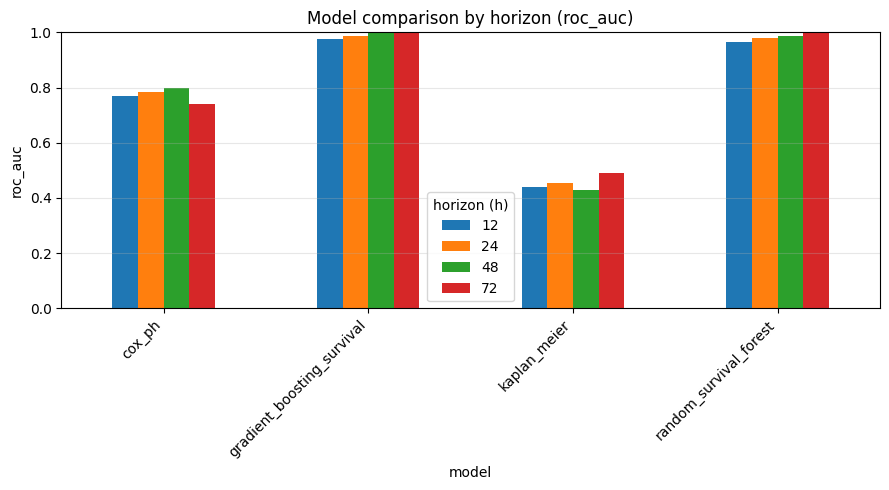

In [74]:
fig = ev.plot_model_comparison(survival_summary, "roc_auc")
save_figure(fig, "survival/model_comparison_rocauc.png")
plt.show()

Zarówno Survival Gradient Boosting, jak i Random Survival Forest osiągają najwyższe wyniki spośród wszystkich modeli analizy przeżycia. Najgorsze wyniki osiąga model Kaplan–Meier, co jest zgodne z oczekiwaniami, ponieważ jest to model nieparametryczny, który nie uwzględnia wpływu cech na ryzyko zdarzenia. Model Coxa wypada lepiej niż KM, ale gorzej niż modele drzewiaste.

Poniżej przedstawiono metrykę konkursową dla kolejnych modeli analizy przeżycia.

In [75]:
surv_comp = (
    survival_summary.sort_values(["hybrid", "model", "horizon_h"], ascending=[False, True, True], na_position="last")
    .drop_duplicates("model")[["model", "hybrid", "c_index", "weighted_brier"]]
    .reset_index(drop=True)
)

save_table(surv_comp, "survival/cv_survival_competition_summary.csv")
surv_comp.round(4)

,model,hybrid,c_index,weighted_brier
0,gradient_boosting_survival,0.9650,0.9322,0.0209
1,random_survival_forest,0.9448,0.9302,0.0490
2,cox_ph,0.7893,0.7443,0.1915
3,kaplan_meier,0.6780,0.5037,0.2473


Analogicznie do modeli klasyfikacyjnych, poniżej przeprowadzono strojenie hiperparametrów dla modeli analizy przeżycia.

In [76]:
TOP_K = 2 if FAST else 3
top_models = surv_comp.dropna(subset=["hybrid"])["model"].head(TOP_K).tolist()
print("tuning:", top_models)

surv_tuned, surv_tuned_oof = ev.evaluate_survival_models(
    survival_models,
    prep,
    train,
    features,
    model_names=top_models,
    n_splits=N_SPLITS,
    tune=True,
)

surv_tuned_comp = (
    surv_tuned.dropna(subset=["hybrid"])
    .sort_values(["hybrid"], ascending=False)
    .assign(model=lambda df: df["model"] + " (tuned)")[["model", "hybrid", "c_index", "weighted_brier"]]
    .drop_duplicates("model")
    .reset_index(drop=True)
)

print("done")

save_table(surv_tuned_comp, "survival/cv_survival_tuned_summary.csv")
surv_tuned_comp.round(4)

tuning: ['gradient_boosting_survival', 'random_survival_forest', 'cox_ph']
done


,model,hybrid,c_index,weighted_brier
0,gradient_boosting_survival (tuned),0.9688,0.9376,0.0179
1,random_survival_forest (tuned),0.9388,0.9304,0.0575
2,cox_ph (tuned),0.8088,0.7934,0.1846


Poniżej wytrenowane na całym zbiorze treningowym modele analizy przeżycia zostają zapisane analogicznie do modeli klasyfikacyjnych.

In [77]:
surv_params = ev.survival_params_from_summary(surv_tuned)
surv_fitted = ev.fit_survival_models(
    survival_models,
    prep,
    train,
    features,
    model_names=top_models,
    params_by_model=surv_params,
)
surv_artifacts = save_model_bundle(
    name="survival_tuned",
    models=surv_fitted,
    features=features,
    metadata={
        "model_family": "survival",
        "models": top_models,
        "horizons": HORIZONS,
        "best_params": surv_params,
        "summary": surv_tuned_comp.to_dict(orient="records"),
    },
    base_dir=ARTIFACTS,
)

print("saved:", surv_artifacts["dir"])
print("zip:", surv_artifacts["zip"])

saved: /content/artifacts/survival_tuned
zip: /content/artifacts/survival_tuned.zip


### 6.5 Porównanie modeli klasyfikacyjnych, regresyjnych i analizy przeżycia

Poniżej przedstawiono porównanie wybranych najlepszych modeli klasyfikacyjnych i analizy przeżycia po strojeniu hiperparametrów oraz towarzyszące im miary konkursowe.

In [78]:
model_comparison = (
    pd.concat(
        [
            df[["model", "hybrid", "c_index", "weighted_brier"]]
            for df in [cls_tuned, surv_tuned_comp]
        ], ignore_index=True
    )
    .sort_values("hybrid", ascending=False, na_position="last")
    .reset_index(drop=True)
)

save_table(model_comparison, "model_family_comparison.csv")
model_comparison.round(4)

,model,hybrid,c_index,weighted_brier
0,decision_tree (tuned),0.9699,0.9348,0.0151
1,gradient_boosting_survival (tuned),0.9688,0.9376,0.0179
2,gradient_boosting (tuned),0.9637,0.9381,0.0253
3,random_forest (tuned),0.9483,0.9321,0.0447
4,random_survival_forest (tuned),0.9388,0.9304,0.0575
5,cox_ph (tuned),0.8088,0.7934,0.1846


Najwyższy Hybrid Score osiąga dostrojone drzewo decyzyjne (`0.9699`), ale przewaga nad najlepszym modelem analizy przeżycia, `gradient_boosting_survival`, jest niewielka (`0.0011`). Model analizy przeżycia osiąga wyższą wartość c-index (`0.9376` vs `0.9348`), natomiast drzewo decyzyjne osiąga wyższą wartość weighted brier score (`0.0151` vs `0.0179`).

Poniższa tabela pokazuje pomocniczą metrykę ROC-AUC oddzielnie dla horyzontów 12h, 24h, 48h i 72h.

In [79]:
cls_tuned_auc = ev.tuned_classification_horizon_metrics(
    cls_tuned_best,
    prep,
    train,
    features,
    n_splits=N_SPLITS,
)

surv_tuned_auc = (
    surv_tuned.dropna(subset=["horizon_h", "roc_auc"])
    .assign(model=lambda df: df["model"] + " (tuned)")[["model", "horizon_h", "roc_auc"]]
    .reset_index(drop=True)
)

tuned_auc = pd.concat([cls_tuned_auc, surv_tuned_auc], ignore_index=True)
save_table(tuned_auc, "tuned_auc_by_horizon.csv")

tuned_auc_table = tuned_auc.pivot(index="model", columns="horizon_h", values="roc_auc").sort_index()

save_table(tuned_auc_table.reset_index(), "tuned_auc_by_horizon_table.csv")
tuned_auc_table.round(3)

horizon_h,12,24,48,72
model,,,,
cox_ph (tuned),0.885,0.860,0.868,0.752
decision_tree (tuned),0.964,0.982,0.996,1.000
gradient_boosting (tuned),0.962,0.986,0.987,1.000
gradient_boosting_survival (tuned),0.974,0.988,0.997,1.000
random_forest (tuned),0.948,0.983,0.992,1.000
random_survival_forest (tuned),0.964,0.975,0.982,0.996


Najlepszą i najbardziej stabilną separację klas osiąga `gradient_boosting_survival`, który ma najwyższe ROC-AUC dla horyzontów 12h, 24h i 48h oraz wynik idealny dla 72h. Modele klasyfikacyjne również osiągają bardzo wysokie wartości, szczególnie dla dłuższych horyzontów, gdzie kilka modeli dochodzi do ROC-AUC bliskiego lub równego `1.0`. Model Coxa wyraźnie odstaje, zwłaszcza dla horyzontu 72h.

Dodatkowo, poniżej przedstawiono pełne krzywe ROC dla każdego horyzontu. Linie ciągłe odpowiadają modelom klasyfikacyjnym, a linie przerywane modelom analizy przeżycia.


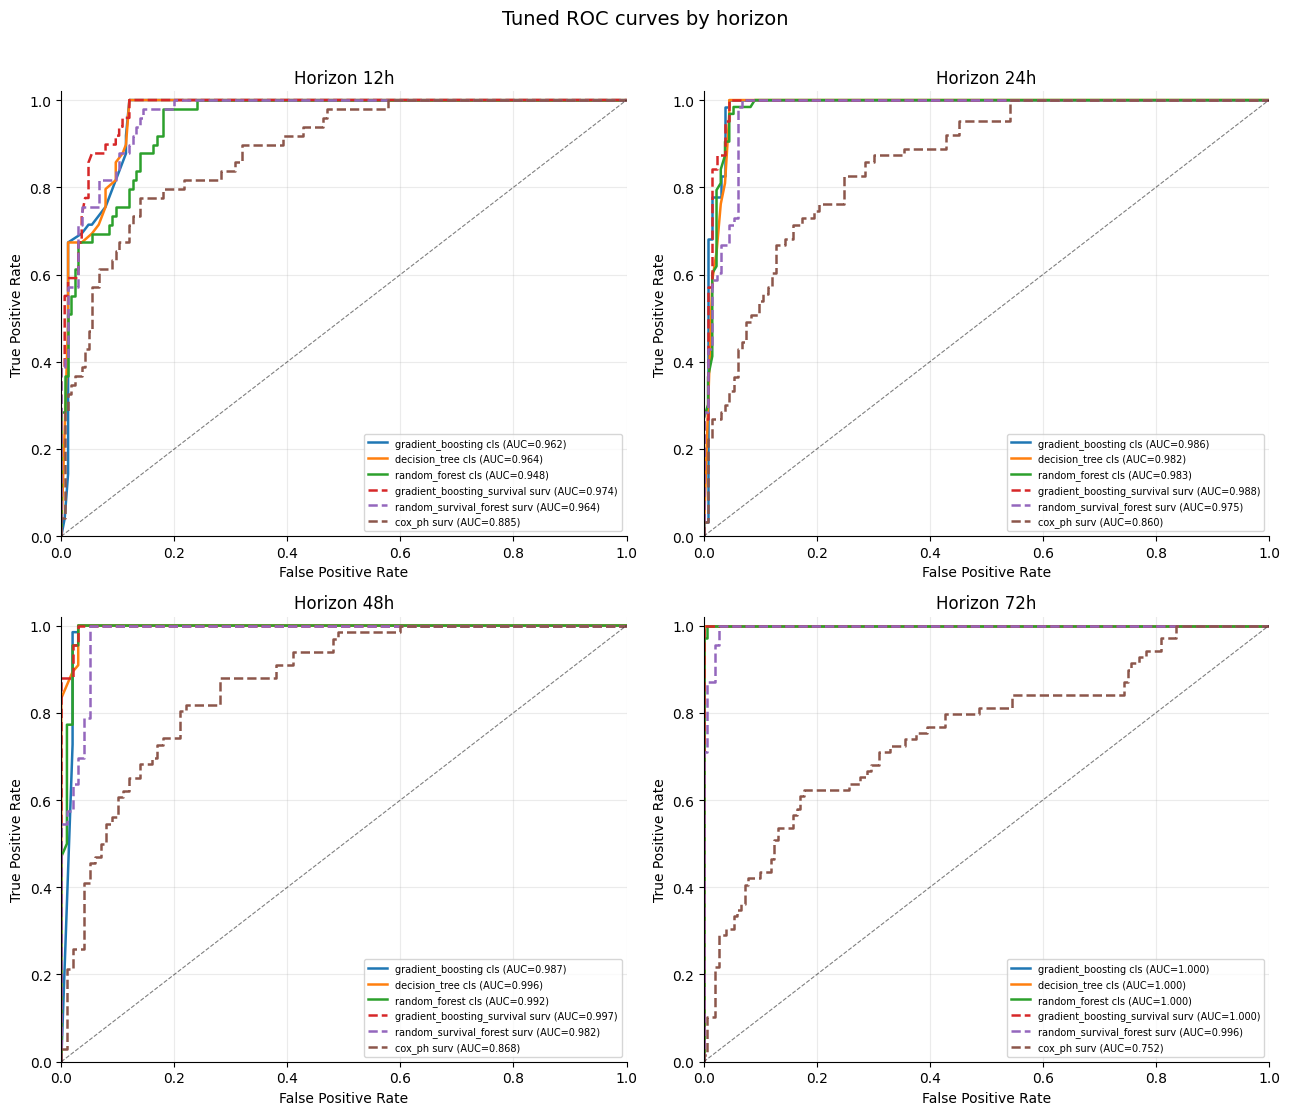

In [80]:
fig = ev.plot_tuned_roc_curves_by_horizon(
    cls_tuned_best,
    prep,
    train,
    features,
    survival_tuned_oof=surv_tuned_oof,
    n_splits=N_SPLITS,
)

save_figure(fig, "tuned_roc_curves_by_horizon.png")
plt.show()

Poniżej przedstawiono analizy stawianych hipotez badawczych H1 oraz H2. Hipoteza H1 zakładała, że modele analizy przeżycia, dzięki bezpośredniemu uwzględnieniu cenzurowania, osiągną wyższy Hybrid Score niż modele klasyfikacyjne. Porównujemy najlepszy dostrojony model z każdej rodziny.

In [81]:
best_cls = cls_tuned.dropna(subset=["hybrid"]).sort_values("hybrid", ascending=False).head(1)
best_surv = surv_tuned_comp.dropna(subset=["hybrid"]).sort_values("hybrid", ascending=False).head(1)

h1_summary = pd.DataFrame(
    [
        {
            "hypothesis": "H1",
            "best_classification_model": best_cls["model"].iloc[0],
            "best_classification_hybrid": best_cls["hybrid"].iloc[0],
            "best_survival_model": best_surv["model"].iloc[0],
            "best_survival_hybrid": best_surv["hybrid"].iloc[0],
            "delta": best_surv["hybrid"].iloc[0] - best_cls["hybrid"].iloc[0],
            "supported": best_surv["hybrid"].iloc[0] > best_cls["hybrid"].iloc[0],
        }
    ]
)
h1_summary.round(4)

,hypothesis,best_classification_model,best_classification_hybrid,best_survival_model,best_survival_hybrid,delta,supported
0,H1,decision_tree (tuned),0.9699,gradient_boosting_survival (tuned),0.9688,-0.0011,False


Hipoteza H1 nie została potwierdzona. Najlepszy model klasyfikacyjny, dostrojone drzewo decyzyjne, osiąga Hybrid Score `0.9699`, natomiast najlepszy model survivalowy, `gradient_boosting_survival`, osiąga `0.9688`. Różnica jest bardzo mała (`-0.0011` na korzyść klasyfikatora), dlatego praktycznie oba podejścia są konkurencyjne, ale formalnie wygrywa wariant klasyfikacyjny.

Hipoteza H2 dotyczyła porównania nieliniowych modeli survivalowych z modelem Coxa. Jako kryterium przyjęto C-index, ponieważ mierzy on zdolność modelu do poprawnego uporządkowania przypadków według czasu/ryzyka zdarzenia.

In [82]:
surv_status = surv_tuned[["model", "hybrid", "c_index"]].drop_duplicates("model")

surv_tree_models = ["random_survival_forest", "gradient_boosting_survival"]
best_tree = surv_status[surv_status["model"].isin(surv_tree_models)].sort_values("c_index", ascending=False).iloc[0]

cox = surv_status.query("model == 'cox_ph'").iloc[0]

h2_summary = pd.DataFrame([{
    "hypothesis": "H2",
    "best_tree_survival_model": best_tree["model"],
    "best_tree_survival_c_index": best_tree["c_index"],
    "cox_c_index": cox["c_index"],
    "delta": best_tree["c_index"] - cox["c_index"],
    "supported": best_tree["c_index"] > cox["c_index"],
}])
h2_summary.round(4)

,hypothesis,best_tree_survival_model,best_tree_survival_c_index,cox_c_index,delta,supported
0,H2,gradient_boosting_survival,0.9376,0.7934,0.1442,True


Hipoteza H2 została potwierdzona. Najlepszy nieliniowy model analizy przeżycia, `gradient_boosting_survival`, uzyskał C-index `0.9376`, podczas gdy model Coxa osiągnął `0.7934`. Różnica `0.1442` wskazuje, że zależności w danych są silnie nieliniowe i lepiej uchwytywane przez modele drzewiaste niż przez półparametryczny model proporcjonalnego hazardu.

### 6.6 Analiza najlepszego modelu — drzewo decyzyjne

Spośród wszystkich wytrenowanych modeli klasyfikacyjnych oraz analizy przeżycia,
jako model finalny wybrano **drzewo decyzyjne**. Decyzja opiera się na
najwyższym wyniku Hybrid Score w walidacji krzyżowej przy jednoczesnej pełnej
interpretowalności — każdą predykcję można prześledzić od korzenia do liścia
bez aproksymacji.

Niniejsza sekcja przedstawia szczegółową analizę wybranego modelu:
strukturę drzew dla każdego horyzontu czasowego, ważność cech, metryki
out-of-fold oraz profile błędów klasyfikacji.


In [83]:
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import plot_tree
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    accuracy_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.base import clone

from src.utils import HORIZONS
from src.preprocessing import engineer_features

warnings.filterwarnings("ignore")

MODELS = ARTIFACTS / "classification_decision_tree"

if not (MODELS / "models.joblib").exists():
    raise FileNotFoundError(f"Missing model bundle: {MODELS}. Run the classification model saving cell first.")

In [84]:
train, test, submission, meta = dl.load_raw(folder=DATA)
features = json.load(open(MODELS / "features.json"))
metadata = json.load(open(MODELS / "metadata.json"))
fitted = joblib.load(MODELS / "models.joblib")

best_params = metadata["best_params"]
eng_names = list(engineer_features(train[features].head(1), use_interactions=True).columns)

print(f"Train: {train.shape} | features: {len(features)} | engineered: {len(eng_names)}")
for h in HORIZONS:
    p = fitted[h].named_steps["model"].get_params()
    print(f"  {h}h -> max_depth={p['max_depth']}, min_samples_leaf={p['min_samples_leaf']}")

Train: (221, 37) | features: 34 | engineered: 41
  12h -> max_depth=3, min_samples_leaf=10
  24h -> max_depth=3, min_samples_leaf=10
  48h -> max_depth=3, min_samples_leaf=10
  72h -> max_depth=3, min_samples_leaf=1


Wczytano zbiór treningowy oraz zapisane artefakty modelu: nazwy cech,
najlepsze hiperparametry i wytrenowane pipeline'y dla każdego horyzontu.
Wypisane parametry drzew potwierdzają że załadowano poprawne, wystrojone
wersje modeli.

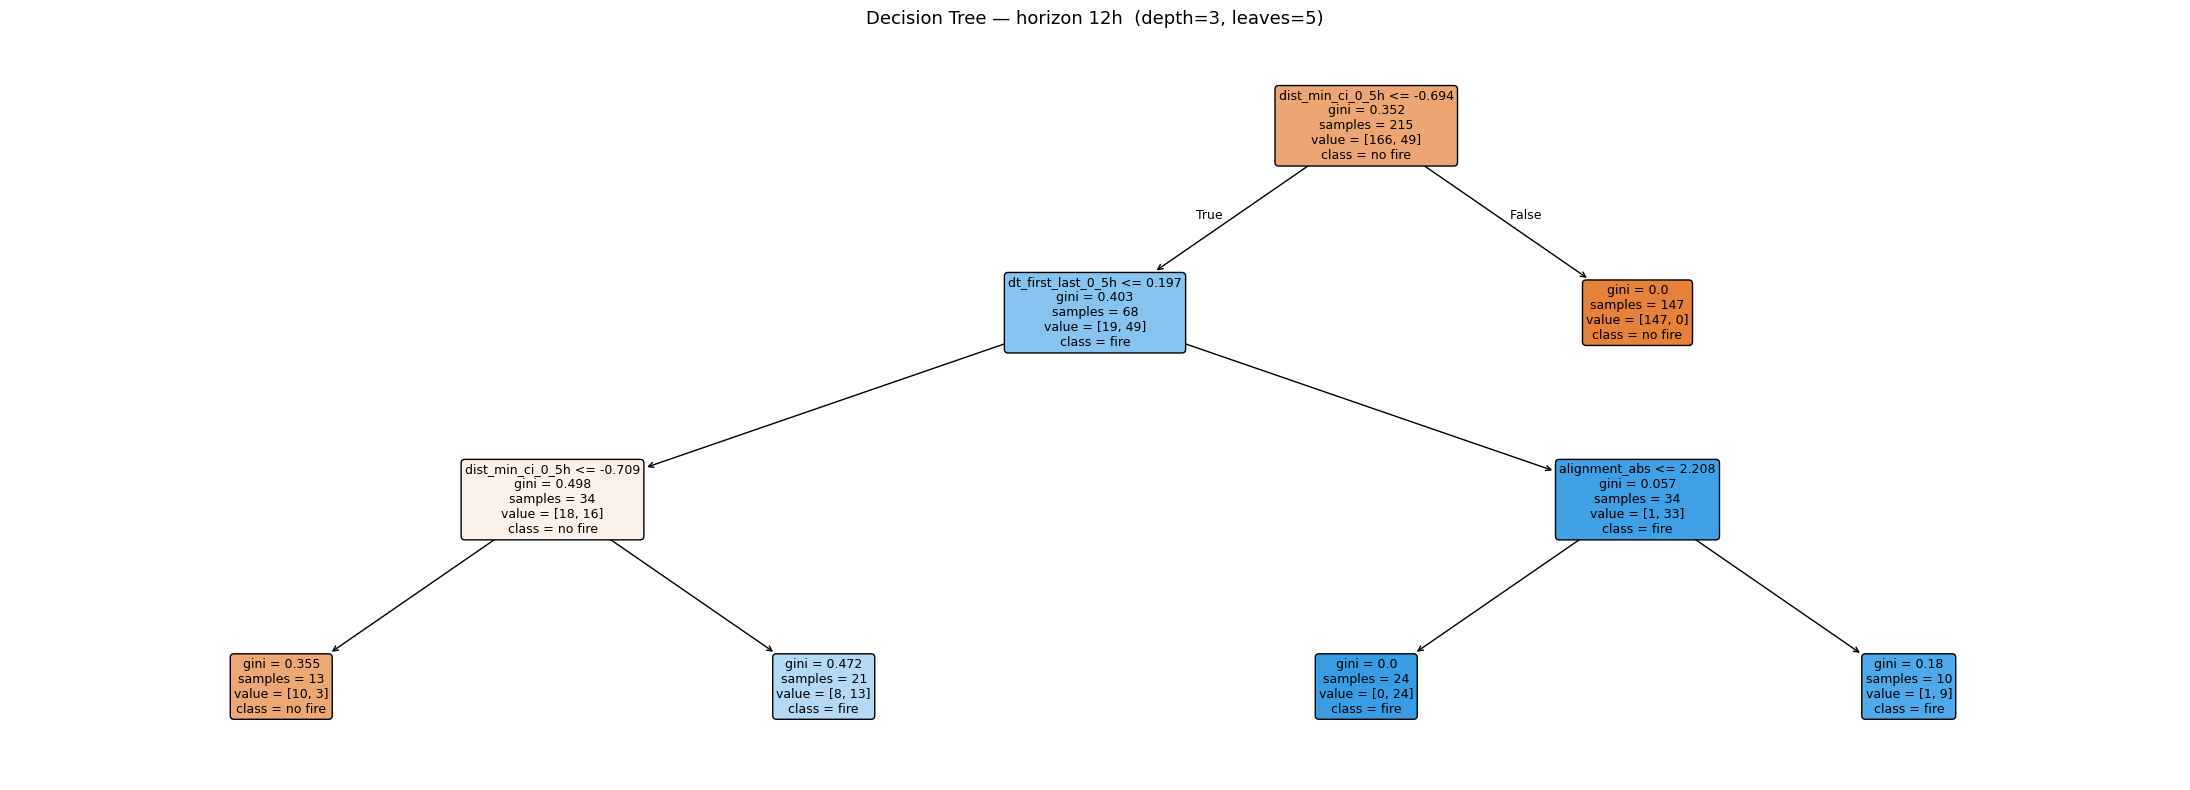

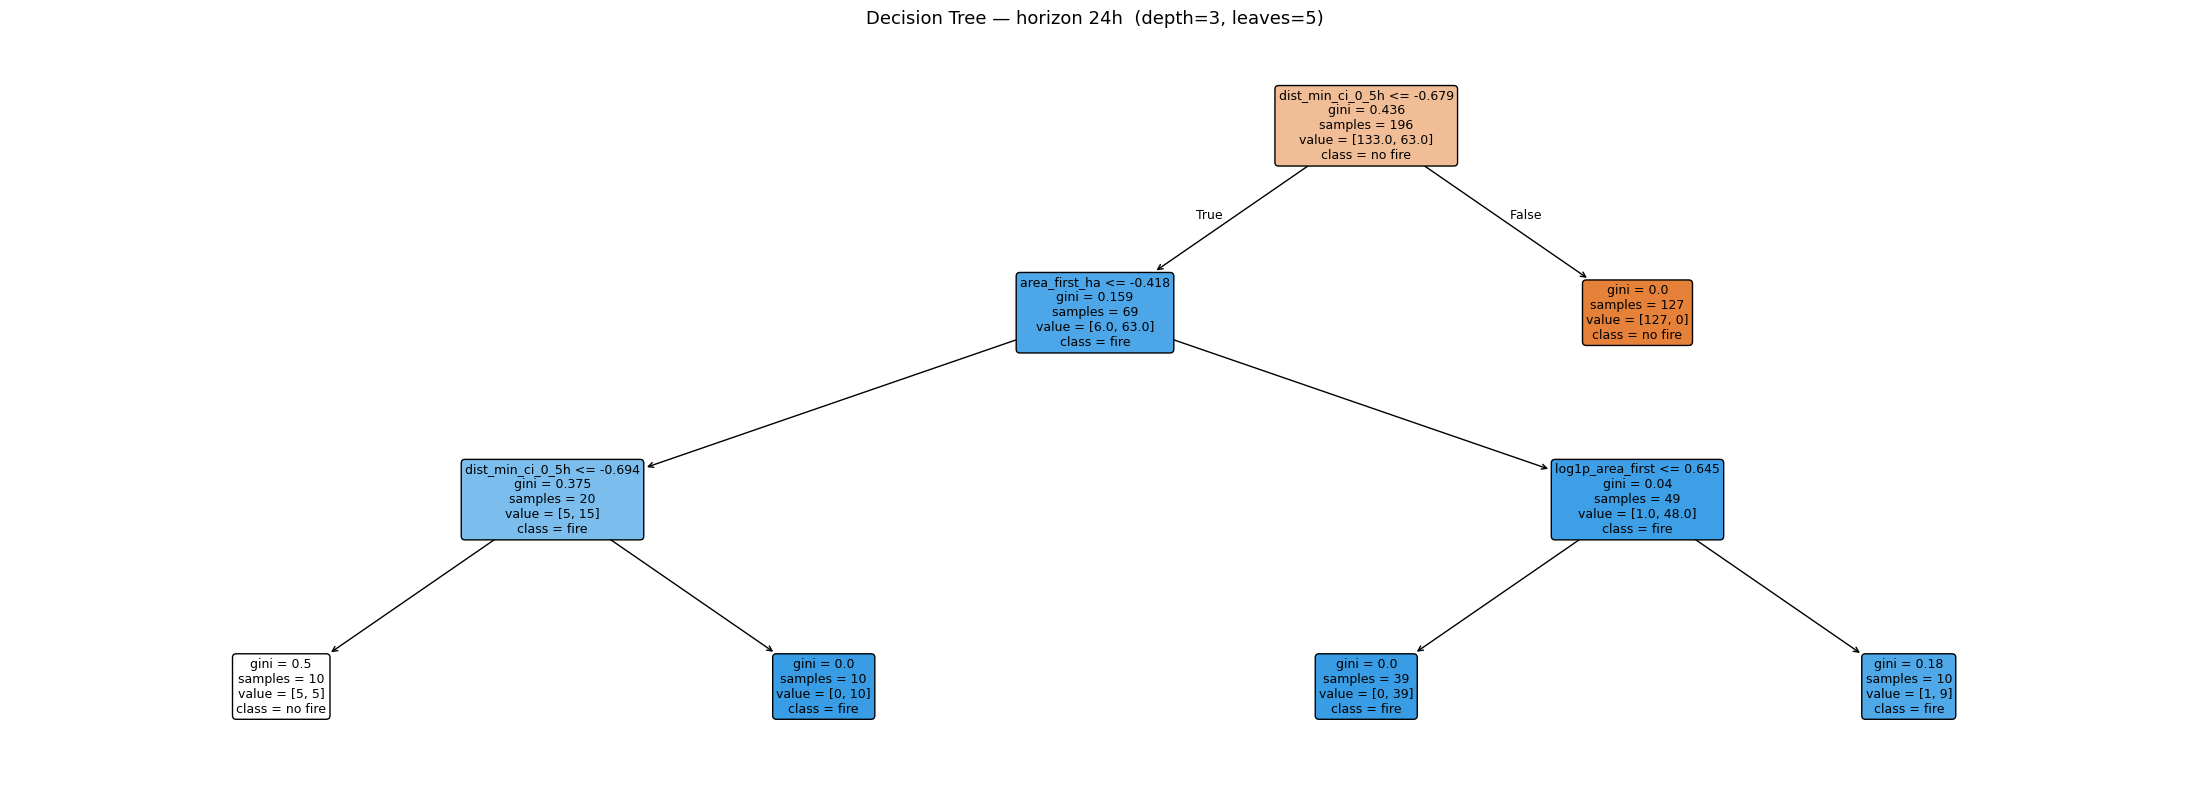

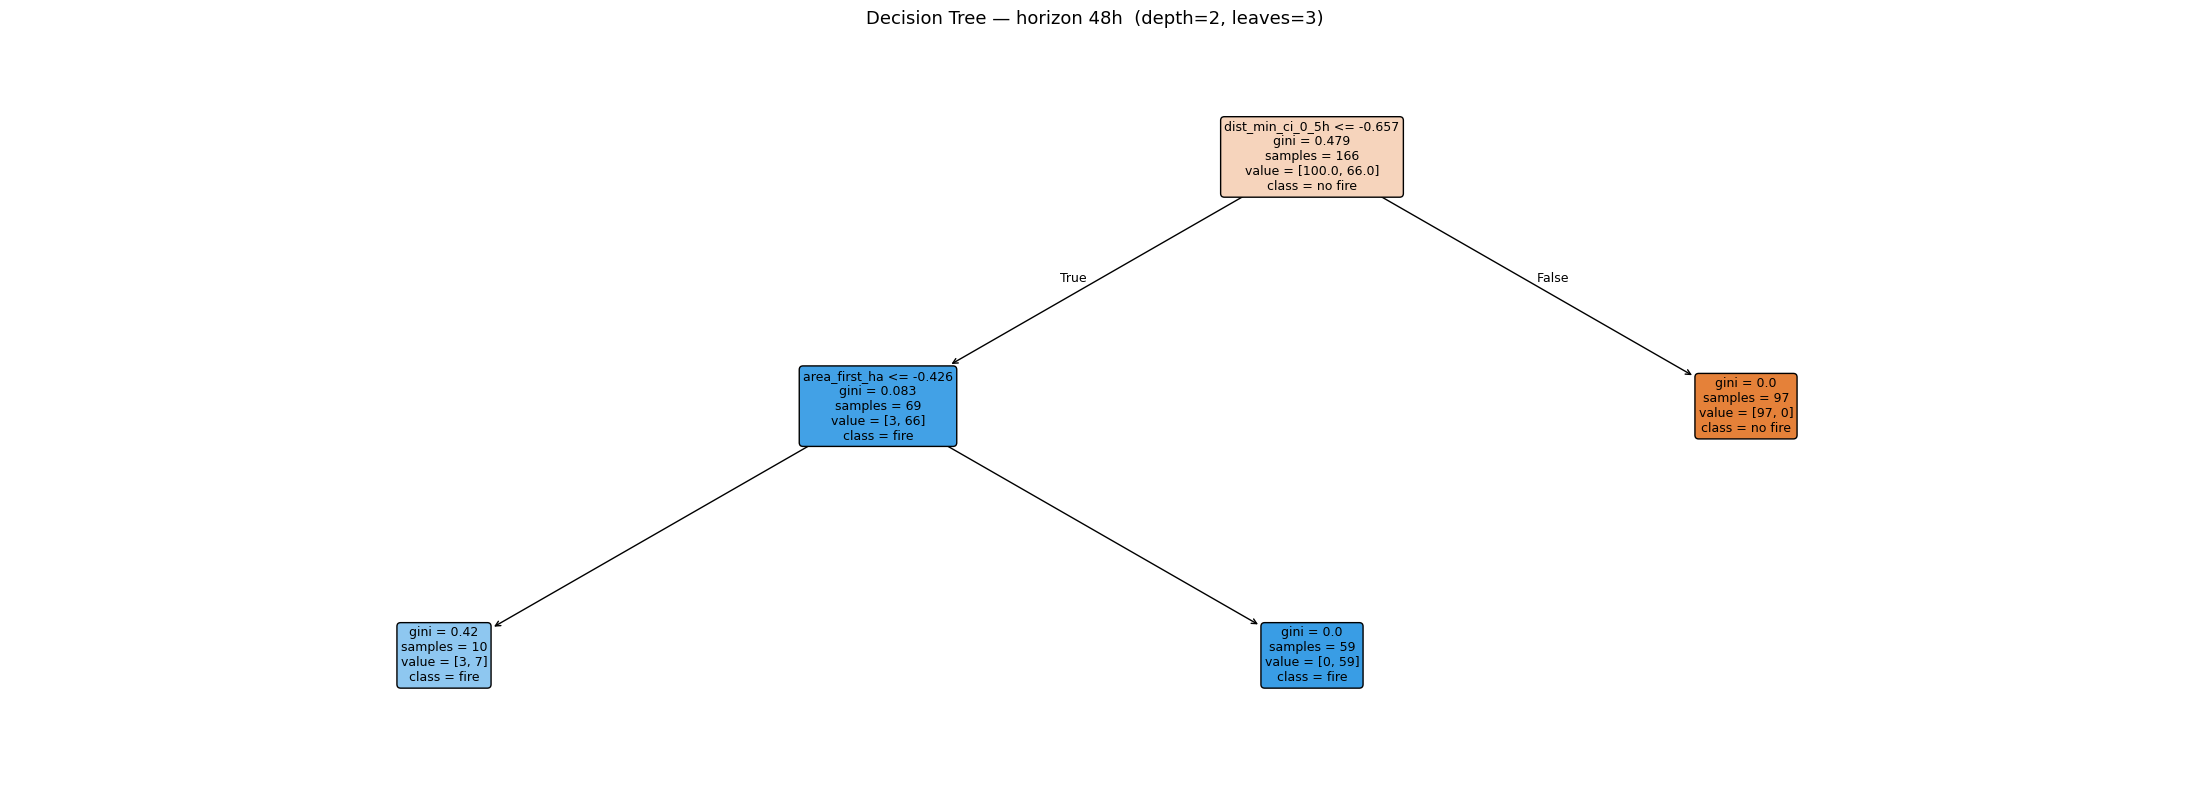

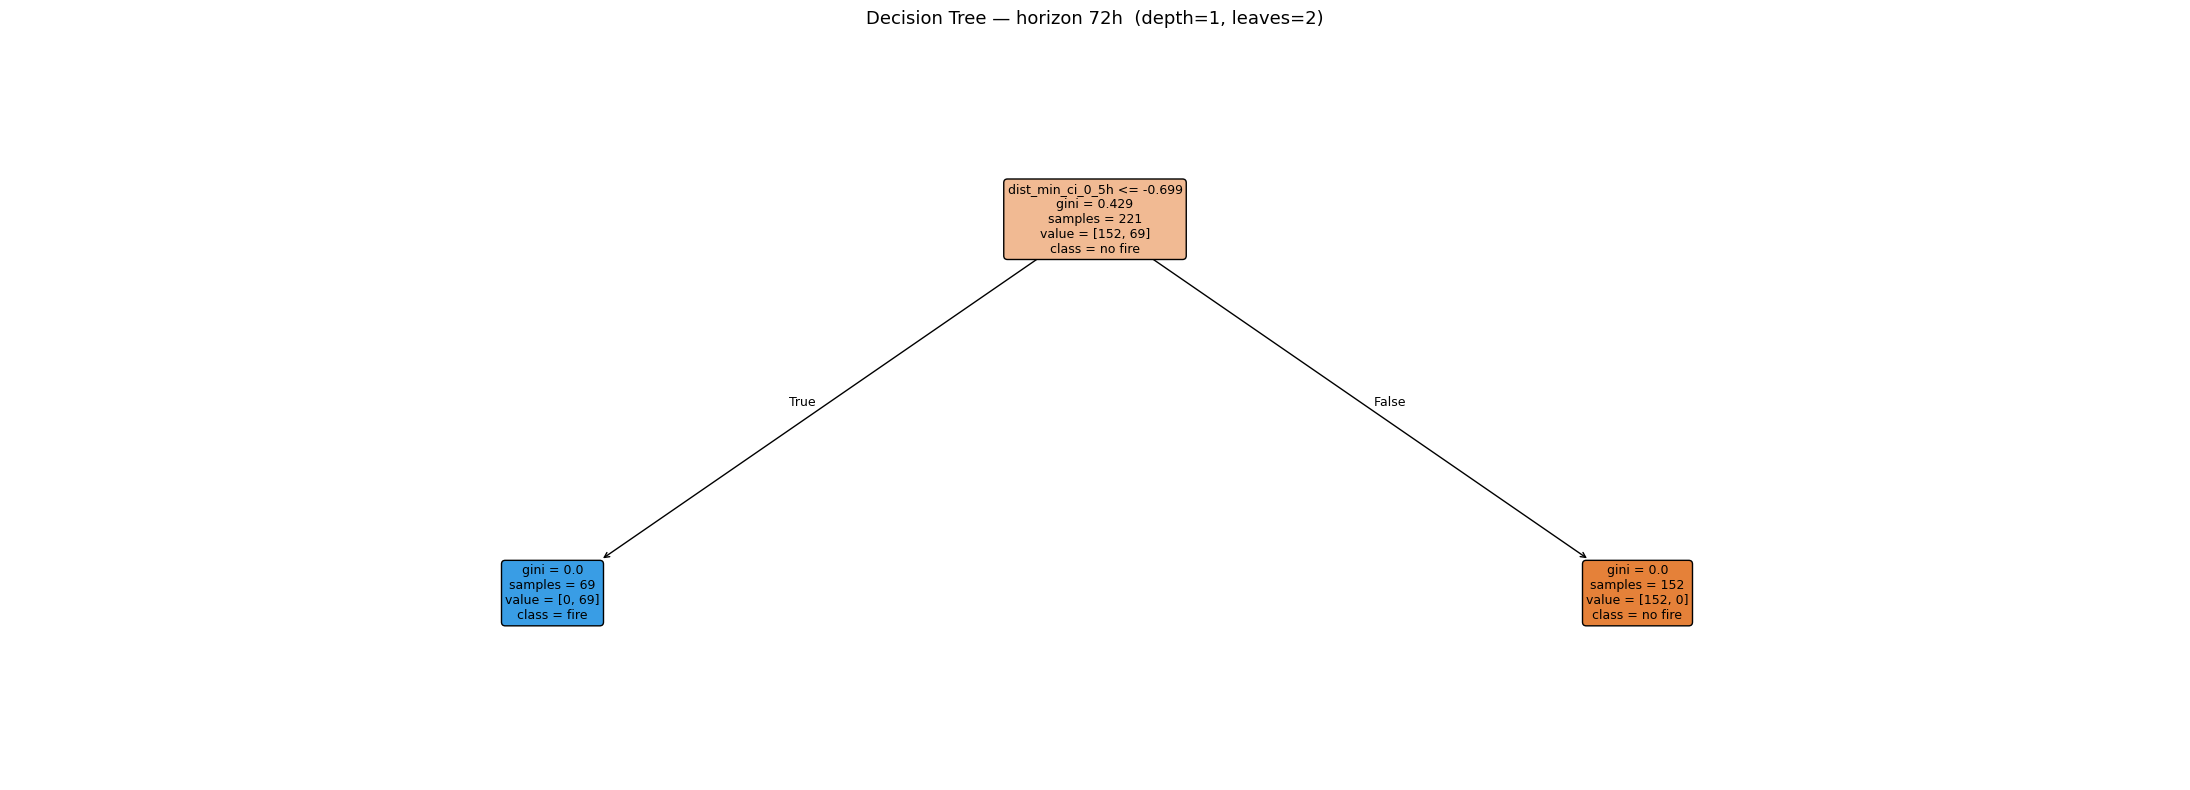

In [85]:
for h in HORIZONS:
    model = fitted[h].named_steps["model"]
    fig, ax = plt.subplots(figsize=(22, 8))
    plot_tree(
        model,
        feature_names=eng_names,
        class_names=["no fire", "fire"],
        filled=True,
        rounded=True,
        fontsize=9,
        ax=ax,
    )
    ax.set_title(
        f"Decision Tree — horizon {h}h  "
        f"(depth={model.get_depth()}, leaves={model.get_n_leaves()})",
        fontsize=13
    )
    plt.tight_layout()
    plt.savefig(RESULTS / f"classification/dt_tree_{h}h.png", dpi=150, bbox_inches="tight")
    plt.show()


Dla każdego horyzontu czasowego (12h, 24h, 48h, 72h) zwizualizowano pełną
strukturę drzewa decyzyjnego. Kolorowanie węzłów odpowiada dominującej klasie
— im ciemniejszy odcień, tym wyższa czystość podziału. Widoczna głębokość
i liczba liści pozwalają ocenić złożoność modelu dla każdego horyzontu.

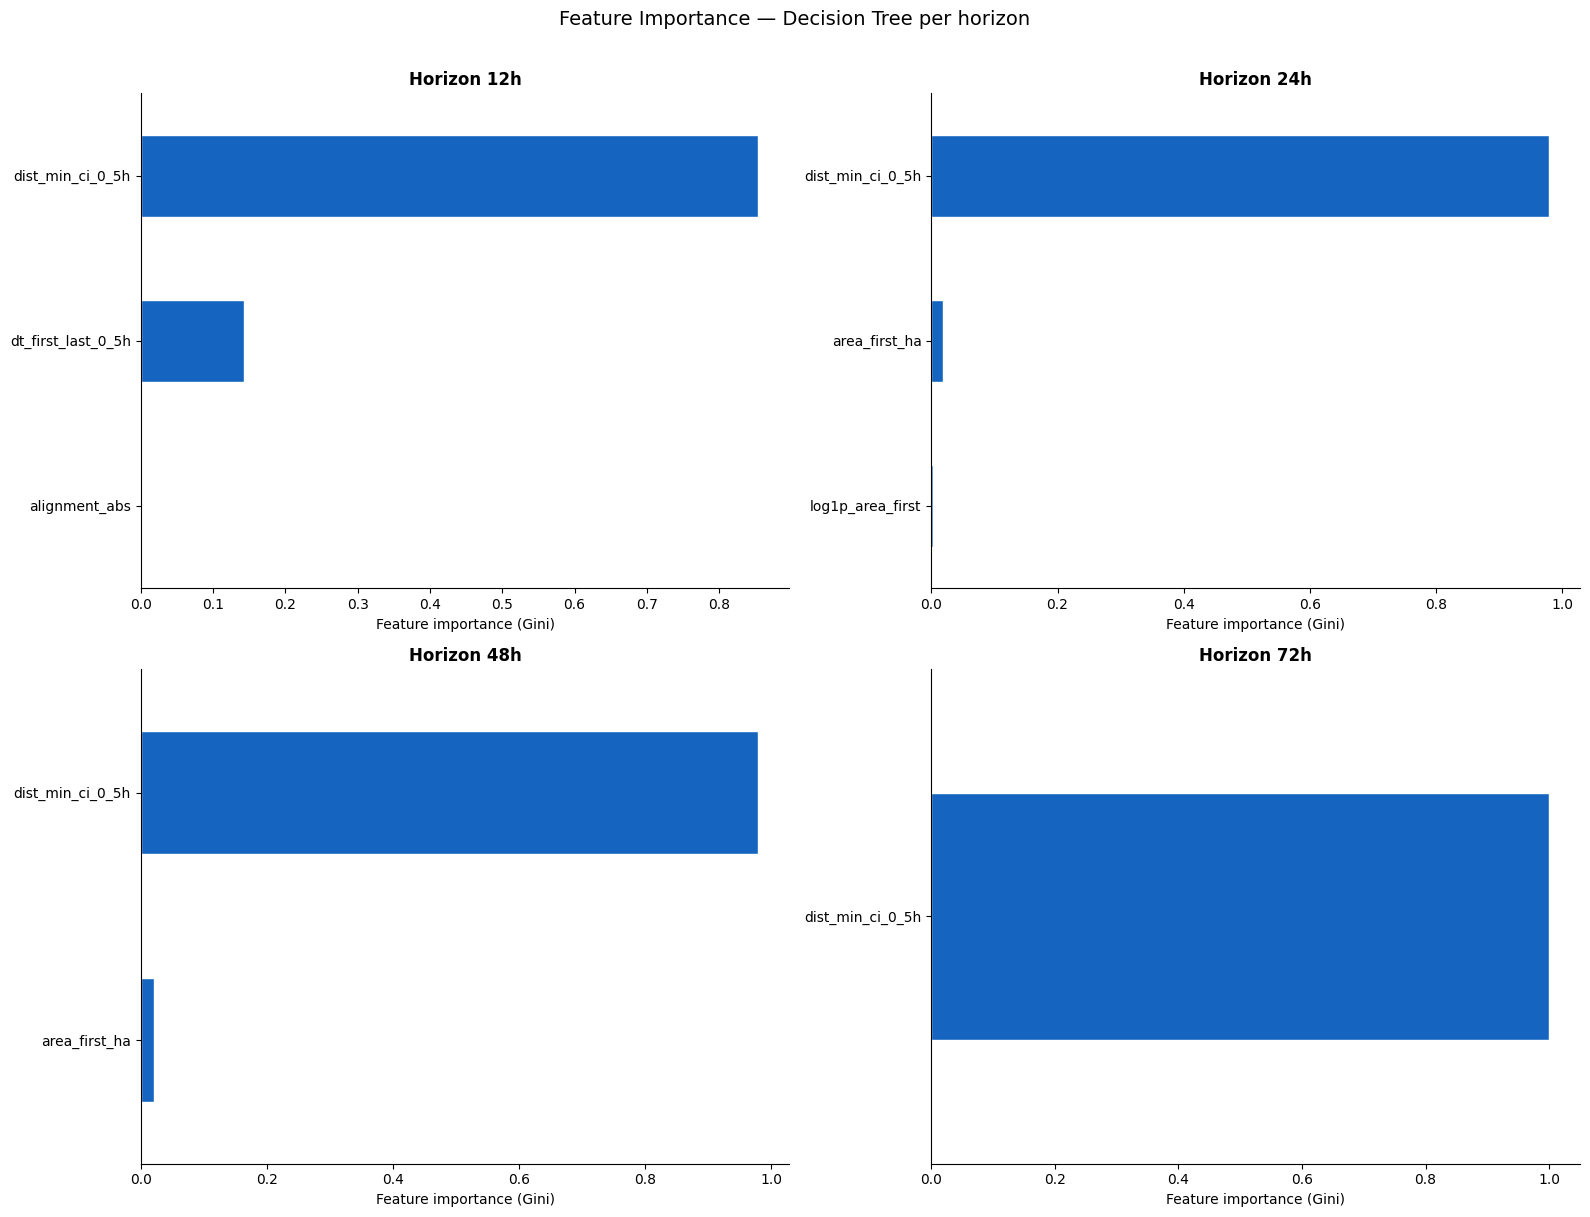

In [86]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, h in enumerate(HORIZONS):
    model = fitted[h].named_steps["model"]
    imp = pd.Series(model.feature_importances_, index=eng_names)
    imp = imp[imp > 0].sort_values()

    ax = axes[idx]
    imp.plot(kind="barh", ax=ax, color="#1565C0", edgecolor="white")
    ax.set_title(f"Horizon {h}h", fontsize=12, fontweight="bold")
    ax.set_xlabel("Feature importance (Gini)")
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

fig.suptitle("Feature Importance — Decision Tree per horizon", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS / "classification/dt_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


Wykres przedstawia ważność cech według kryterium Gini dla każdego horyzontu
osobno. Uwzględniono wyłącznie cechy z niezerową ważnością. Dominujące cechy
różnią się między horyzontami — im dłuższy horyzont, tym większą rolę
odgrywają cechy dynamiczne (prędkość zbliżania, tempo wzrostu powierzchni).

In [87]:
N_SPLITS = 5
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

oof  = {}
rows = []

for h in HORIZONS:
    usable, y_arr = dl.horizon_labels(train, h)
    X = train.loc[usable, features].reset_index(drop=True)
    y = pd.Series(y_arr[usable]).reset_index(drop=True)

    base_model = fitted[h].named_steps["model"]
    pipe = Pipeline([
        ("pre",   pp.build_preprocessor(use_interactions=True, scale=True)),
        ("model", clone(base_model)),
    ])

    prob = cross_val_predict(pipe, X, y, cv=cv, method="predict_proba")[:, 1]
    pred = (prob >= 0.5).astype(int)

    oof[h] = {"y_true": y.to_numpy(), "prob": prob, "pred": pred}

    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    rows.append({
        "Horizon":     f"{h}h",
        "ROC-AUC":     round(roc_auc_score(y, prob), 4),
        "Brier":       round(brier_score_loss(y, prob), 4),
        "F1":          round(f1_score(y, pred, zero_division=0), 4),
        "Accuracy":    round(accuracy_score(y, pred), 4),
        "Sensitivity": round(tp / (tp + fn) if (tp + fn) else 0, 4),
        "Specificity": round(tn / (tn + fp) if (tn + fp) else 0, 4),
        "N (usable)":  int(usable.sum()),
        "Positives":   int(y.sum()),
    })

metrics_df = pd.DataFrame(rows).set_index("Horizon")
display(metrics_df)

,ROC-AUC,Brier,F1,Accuracy,Sensitivity,Specificity,N (usable),Positives
Horizon,,,,,,,,
12h,0.9645,0.0702,0.7723,0.8930,0.7959,0.9217,215,49
24h,0.9819,0.0301,0.9545,0.9694,1.0000,0.9549,196,63
48h,0.9963,0.0173,0.9778,0.9819,1.0000,0.9700,166,66
72h,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,221,69


Metryki obliczono metodą out-of-fold (OOF) z 5-krotną walidacją krzyżową
ze stratyfikacją — predykcje dla każdej próbki pochodzą wyłącznie z foldów,
w których dana próbka nie brała udziału w treningu. Dzięki temu wyniki
są wolne od przeuczenia i odzwierciedlają rzeczywistą zdolność generalizacji
modelu. Dla każdego horyzontu raportowane są: ROC-AUC, Brier Score, F1,
dokładność, czułość i swoistość.

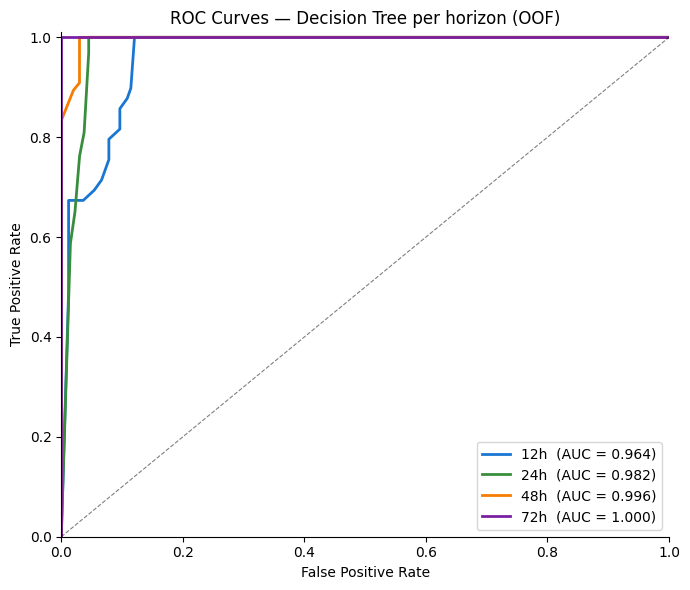

In [88]:
colors = ["#1976D2", "#388E3C", "#F57C00", "#7B1FA2"]

fig, ax = plt.subplots(figsize=(7, 6))
for idx, h in enumerate(HORIZONS):
    fpr, tpr, _ = roc_curve(oof[h]["y_true"], oof[h]["prob"])
    auc = roc_auc_score(oof[h]["y_true"], oof[h]["prob"])
    ax.plot(fpr, tpr, color=colors[idx], lw=2, label=f"{h}h  (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Decision Tree per horizon (OOF)")
ax.legend()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.01)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(RESULTS / "classification/dt_roc.png", dpi=150, bbox_inches="tight")
plt.show()


Krzywe ROC przedstawiają zdolność dyskryminacyjną modelu dla każdego horyzontu.
Wraz z wydłużaniem horyzontu czasowego pole pod krzywą (AUC) rośnie — model
przewiduje pożary z większą pewnością dla zdarzeń odleglejszych w czasie,
co jest zgodne z charakterystyką danych: dłuższy horyzont oznacza bardziej
zaawansowane stadium rozwoju pożaru i wyraźniejsze sygnały w cechach.

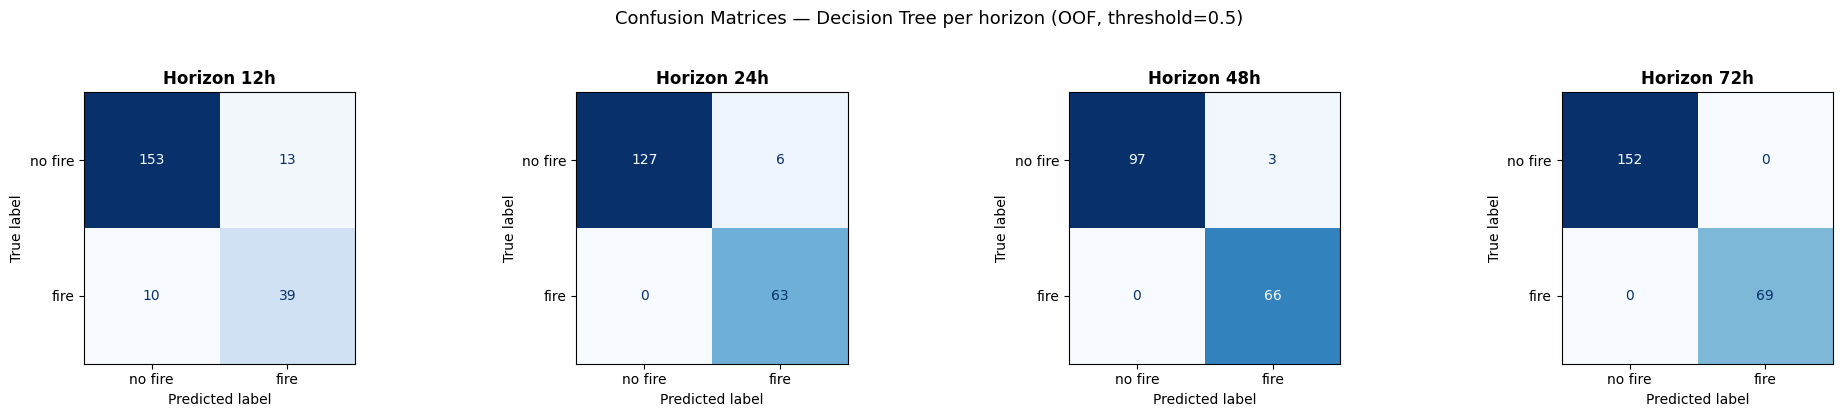

In [89]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(5 * len(HORIZONS), 4))

for ax, h in zip(axes, HORIZONS):
    cm = confusion_matrix(oof[h]["y_true"], oof[h]["pred"])
    ConfusionMatrixDisplay(cm, display_labels=["no fire", "fire"]).plot(
        ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(f"Horizon {h}h", fontsize=12, fontweight="bold")

fig.suptitle("Confusion Matrices — Decision Tree per horizon (OOF, threshold=0.5)",
             fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig(RESULTS / "classification/dt_confusion.png", dpi=150, bbox_inches="tight")
plt.show()


Macierze pomyłek pokazują rozkład predykcji modelu względem prawdziwych etykiet
przy progu decyzyjnym 0.5. Kluczowe z perspektywy zastosowania są wyniki
False Negative (FN) — przypadki pożarów sklasyfikowanych jako brak zagrożenia.
Wraz z wydłużaniem horyzontu liczba FN maleje, co potwierdza wzrost czułości
modelu dla dłuższych horyzontów obserwowany w tabeli metryk.

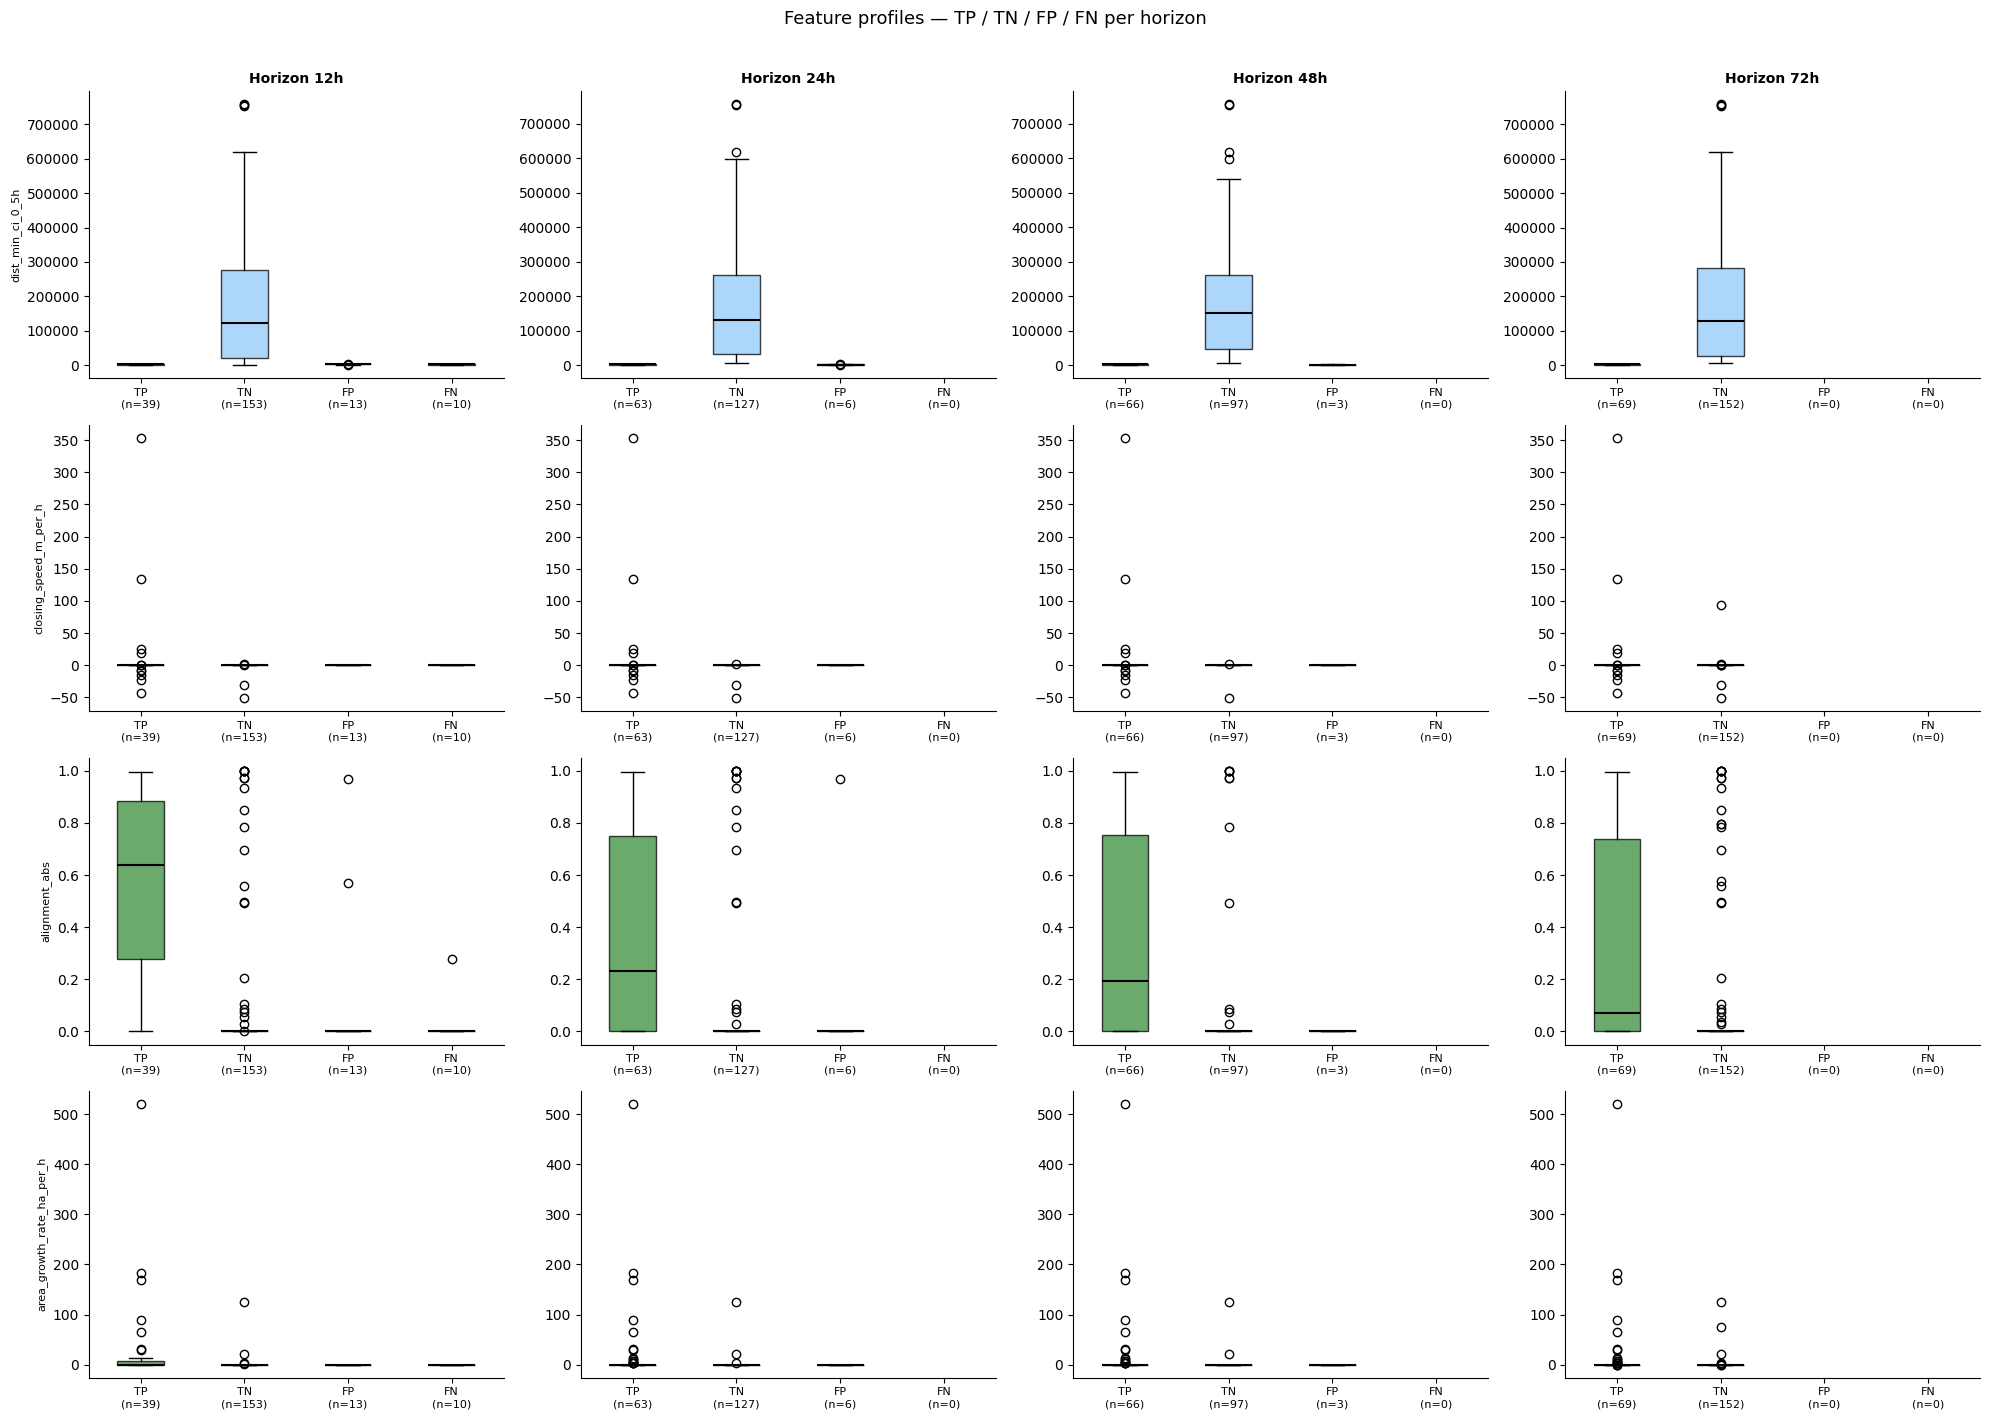

In [90]:
KEY = [f for f in [
    "dist_min_ci_0_5h", "closing_speed_m_per_h",
    "alignment_abs", "area_growth_rate_ha_per_h"
] if f in features]

fig, axes = plt.subplots(len(KEY), len(HORIZONS),
                         figsize=(5 * len(HORIZONS), 3.5 * len(KEY)))

GROUP_COLORS = {"TP": "#388E3C", "TN": "#90CAF9", "FP": "#F57C00", "FN": "#C62828"}

for col, h in enumerate(HORIZONS):
    usable, _ = dl.horizon_labels(train, h)
    idx = np.where(usable)[0]
    y_t, pr, pd_ = oof[h]["y_true"], oof[h]["prob"], oof[h]["pred"]

    masks = {
        "TP": (pd_ == 1) & (y_t == 1),
        "TN": (pd_ == 0) & (y_t == 0),
        "FP": (pd_ == 1) & (y_t == 0),
        "FN": (pd_ == 0) & (y_t == 1),
    }

    for row, feat in enumerate(KEY):
        ax = axes[row][col] if len(KEY) > 1 else axes[col]
        vals = train.iloc[idx][feat].to_numpy()
        data = [vals[m] for m in masks.values()]
        counts = [m.sum() for m in masks.values()]

        bp = ax.boxplot(data, patch_artist=True,
                        medianprops=dict(color="black", linewidth=1.5))
        for patch, label in zip(bp["boxes"], GROUP_COLORS):
            patch.set_facecolor(GROUP_COLORS[label])
            patch.set_alpha(0.75)

        ax.set_xticks(range(1, 5))
        ax.set_xticklabels(
            [f"{l}\n(n={c})" for l, c in zip(masks.keys(), counts)], fontsize=8
        )
        if col == 0:
            ax.set_ylabel(feat, fontsize=8)
        if row == 0:
            ax.set_title(f"Horizon {h}h", fontsize=10, fontweight="bold")
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

fig.suptitle("Feature profiles — TP / TN / FP / FN per horizon", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS / "classification/dt_error_profile.png", dpi=150, bbox_inches="tight")
plt.show()


Wykresy pudełkowe przedstawiają rozkład wartości kluczowych cech w podziale
na cztery grupy predykcji: TP, TN, FP i FN. Pozwala to zidentyfikować
wzorce błędów — np. czy fałszywie negatywne przypadki (FN) skupiają się
w określonym zakresie odległości lub prędkości zbliżania. Taka analiza
wskazuje, w jakich warunkach model jest najmniej pewny i gdzie warto
rozważyć obniżenie progu decyzyjnego.

In [91]:
print("=" * 50)
print("  Decision Tree — OOF metrics per horizon")
print("=" * 50)
display(metrics_df)

print("\nTop feature per horizon:")
for h in HORIZONS:
    imp = pd.Series(
        fitted[h].named_steps["model"].feature_importances_, index=eng_names
    )
    top = imp.idxmax()
    print(f"  {h}h  ->  {top}  ({imp[top]:.3f})")

  Decision Tree — OOF metrics per horizon


,ROC-AUC,Brier,F1,Accuracy,Sensitivity,Specificity,N (usable),Positives
Horizon,,,,,,,,
12h,0.9645,0.0702,0.7723,0.8930,0.7959,0.9217,215,49
24h,0.9819,0.0301,0.9545,0.9694,1.0000,0.9549,196,63
48h,0.9963,0.0173,0.9778,0.9819,1.0000,0.9700,166,66
72h,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,221,69



Top feature per horizon:
  12h  ->  dist_min_ci_0_5h  (0.854)
  24h  ->  dist_min_ci_0_5h  (0.979)
  48h  ->  dist_min_ci_0_5h  (0.980)
  72h  ->  dist_min_ci_0_5h  (1.000)


## 7. Podsumowanie i wnioski

Najlepszy wynik końcowy uzyskało dostrojone drzewo decyzyjne z Hybrid Score równym `0.9699`, C-index `0.9348` i Weighted Brier Score `0.0151`. Bardzo zbliżony wynik osiągnął najlepszy model analizy przeżycia, `gradient_boosting_survival`, z Hybrid Score `0.9688`, C-index `0.9376` i Weighted Brier Score `0.0179`. Oznacza to, że model analizy przeżycia lepiej porządkował przypadki według ryzyka, ale drzewo decyzyjne dawało nieco lepiej skalibrowane prawdopodobieństwa, co przełożyło się na minimalnie wyższy Hybrid Score.

Hipoteza H1 nie została potwierdzona. Modele analizy przeżycia nie osiągnęły wyższego Hybrid Score niż najlepszy model klasyfikacyjny. Różnica między najlepszym modelem klasyfikacyjnym i analizy przeżycia była jednak bardzo mała, dlatego oba podejścia można uznać za praktycznie konkurencyjne.

Hipoteza H2 została potwierdzona. Nieliniowy model survivalowy `gradient_boosting_survival` uzyskał C-index `0.9376`, natomiast model Coxa `0.7934`. Różnica wskazuje, że zależności w danych są nieliniowe i lepiej modelowane przez metody drzewiaste niż przez półparametryczny model proporcjonalnego hazardu.

Hipoteza H3 nie została potwierdzona. Dodanie cech interakcyjnych do modeli liniowych nie poprawiło wyników: Hybrid Score dla wariantu bez interakcji wyniósł `0.8701`, a po dodaniu interakcji `0.8689`. Sugeruje to, że sama inżynieria cech wyższego rzędu nie była wystarczająca, aby modele liniowe dorównały metodom drzewiastym.

Jako model finalny wybrano dostrojone drzewo decyzyjne. Decyzja wynika z najwyższego Hybrid Score, bardzo dobrych wyników out-of-fold oraz wysokiej interpretowalności. Dla kolejnych horyzontów model osiągnął ROC-AUC od `0.9645` dla 12h do `1.0000` dla 72h. Najtrudniejszym horyzontem był 12h, gdzie model miał niższą czułość (`0.7959`), natomiast dla 24h, 48h i 72h wyniki były bardzo wysokie.

Najważniejszym ograniczeniem jest niewielki rozmiar zbioru treningowego. Bardzo wysokie wyniki, szczególnie dla horyzontu 72h, należy interpretować ostrożnie, ponieważ mogą wynikać zarówno z łatwiejszej separacji klas w dłuższym horyzoncie, jak i z ograniczonej liczby obserwacji. Dodatkowo strojenie hiperparametrów wykonywano w ramach dostępnych danych, więc końcowe wyniki mogą być lekko optymistyczne.